# 🌳 Classification and Regression Trees (CART)
## Machine Learning — Discussion Notebook

**Topics Covered:**
1. CART in a Nutshell
2. Making Predictions with CART
3. Growing a Tree
4. Splitting Criteria for Regression
5. Splitting Criteria for Classification
   - 5.1 Complete Worked Example: Gini & Entropy on the Iris Dataset
6. Computation Aspects of Finding Splits
7. Stopping Criteria and Pruning
   - 7.5 Surrogate Splits in CART
8. Advantages and Disadvantages
9. Use Case: End-to-End Example

---


## 1. CART in a Nutshell

**Classification and Regression Trees (CART)**, introduced by Breiman et al. (1984), is one of the most fundamental and interpretable supervised learning algorithms. The core idea is elegantly simple:

> **Recursively partition the feature space into axis-aligned rectangular regions, and assign a constant prediction within each region.**

### Key Properties
| Property | Description |
|:---------|:------------|
| **Type** | Non-parametric supervised learning |
| **Output** | Classification (class label) or Regression (real value) |
| **Splits** | Always binary (yes/no) for CART specifically |
| **Prediction** | Majority vote (classification) or mean (regression) in leaf |
| **Interpretability** | High — can be visualized as a flowchart |

### How It Differs from Other Tree Algorithms
- **ID3 / C4.5** (Quinlan): Multi-way splits, information gain / gain ratio, classification only
- **CART** (Breiman): Binary splits only, Gini / MSE, handles both classification and regression
- **CHAID**: Chi-square-based splitting, can produce multi-way splits

In this notebook, we focus exclusively on **CART** — the algorithm behind `DecisionTreeClassifier` and `DecisionTreeRegressor` in scikit-learn.


In [ ]:
# Setup — run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, mean_squared_error, r2_score,
                             classification_report, confusion_matrix)
from sklearn.datasets import make_moons, make_circles, load_iris, load_wine
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("✅ All libraries loaded successfully.")


✅ All libraries loaded successfully.


## 2. Making Predictions with CART

A trained decision tree makes predictions by traversing from the **root node** to a **leaf node**:

1. Start at the root.
2. At each internal node, evaluate the splitting condition (e.g., `feature_j ≤ threshold`).
3. Go left if the condition is True, right if False.
4. Repeat until a leaf is reached.
5. Return the leaf's value: **majority class** (classification) or **mean of training samples** (regression).

### Prediction Complexity
- **Time:** $O(\log_2 n)$ for a balanced tree of depth $d$, where you traverse at most $d$ nodes.
- **Space:** $O(1)$ additional space per prediction (just pointer traversal).

Let's see this in action with a simple example.


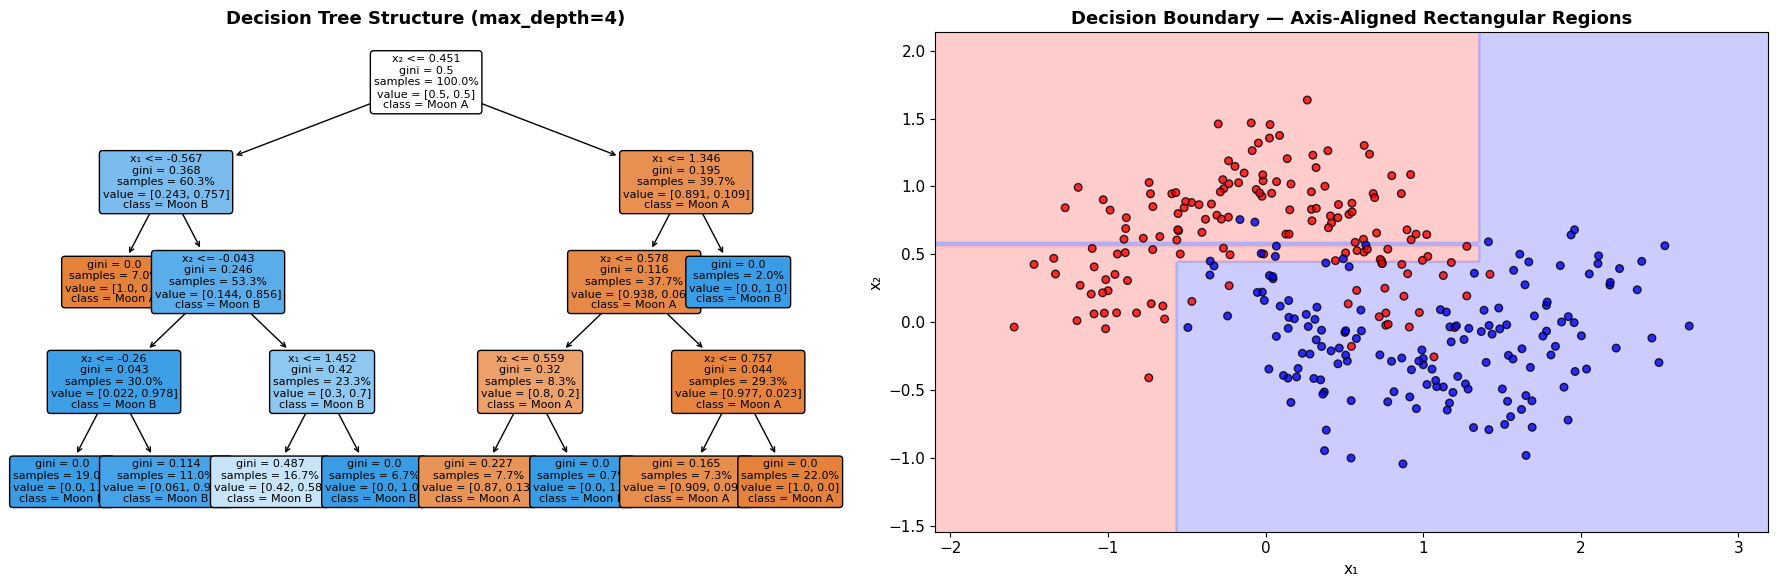

Training accuracy: 0.9067
Number of leaves: 10
Tree depth: 4


In [ ]:
# A simple 2D classification example
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X, y)

# Visualize the tree
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Decision Tree Structure
plot_tree(clf, feature_names=['x₁', 'x₂'], class_names=['Moon A', 'Moon B'],
          filled=True, rounded=True, fontsize=8, ax=axes[0],
          proportion=True, impurity=True)
axes[0].set_title('Decision Tree Structure (max_depth=4)', fontsize=13, fontweight='bold')

# Right: Decision Boundary
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

axes[1].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolors='k', s=30, alpha=0.8)
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')
axes[1].set_title('Decision Boundary — Axis-Aligned Rectangular Regions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Training accuracy: {clf.score(X, y):.4f}")
print(f"Number of leaves: {clf.get_n_leaves()}")
print(f"Tree depth: {clf.get_depth()}")


In [ ]:
# Text representation — trace the path of a single prediction
print("=== Tree Rules (text) ===\n")
print(export_text(clf, feature_names=['x1', 'x2'], show_weights=True))

# Trace a single sample
sample = X[0:1]
print(f"\nSample: x1={sample[0,0]:.3f}, x2={sample[0,1]:.3f}")
print(f"True label: {y[0]}")
print(f"Predicted: {clf.predict(sample)[0]}")
print(f"Predicted probabilities: {clf.predict_proba(sample)[0]}")

# Show the decision path
decision_path = clf.decision_path(sample)
node_ids = decision_path.indices
print(f"Nodes visited: {node_ids}")


=== Tree Rules (text) ===

|--- x2 <= 0.45
|   |--- x1 <= -0.57
|   |   |--- weights: [21.00, 0.00] class: 0
|   |--- x1 >  -0.57
|   |   |--- x2 <= -0.04
|   |   |   |--- x2 <= -0.26
|   |   |   |   |--- weights: [0.00, 57.00] class: 1
|   |   |   |--- x2 >  -0.26
|   |   |   |   |--- weights: [2.00, 31.00] class: 1
|   |   |--- x2 >  -0.04
|   |   |   |--- x1 <= 1.45
|   |   |   |   |--- weights: [21.00, 29.00] class: 1
|   |   |   |--- x1 >  1.45
|   |   |   |   |--- weights: [0.00, 20.00] class: 1
|--- x2 >  0.45
|   |--- x1 <= 1.35
|   |   |--- x2 <= 0.58
|   |   |   |--- x2 <= 0.56
|   |   |   |   |--- weights: [20.00, 3.00] class: 0
|   |   |   |--- x2 >  0.56
|   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |--- x2 >  0.58
|   |   |   |--- x2 <= 0.76
|   |   |   |   |--- weights: [20.00, 2.00] class: 0
|   |   |   |--- x2 >  0.76
|   |   |   |   |--- weights: [66.00, 0.00] class: 0
|   |--- x1 >  1.35
|   |   |--- weights: [0.00, 6.00] class: 1


Sample: x1=0.864, x2

## 3. Growing a Tree

### The Recursive Partitioning Algorithm

CART grows a tree using a **top-down, greedy** approach often called **recursive binary splitting**:

```
function GrowTree(D, features):
    if stopping_criterion_met(D):
        return create_leaf(D)
    
    best_feature, best_threshold = find_best_split(D, features)
    D_left  = {x ∈ D : x[best_feature] ≤ best_threshold}
    D_right = {x ∈ D : x[best_feature] > best_threshold}
    
    left_child  = GrowTree(D_left, features)
    right_child = GrowTree(D_right, features)
    
    return create_node(best_feature, best_threshold, left_child, right_child)
```

### Why Greedy?
Finding the globally optimal tree is **NP-complete** (Hyafil & Rivest, 1976). CART makes the **locally optimal** choice at each node — the split that maximizes impurity reduction *right now*, without looking ahead.

### Key Decisions at Each Node
1. **Which feature** to split on?
2. **What threshold** to use?
3. **Should we stop** splitting?

The answers depend on the **splitting criterion** (next two sections) and the **stopping rules** (Section 7).


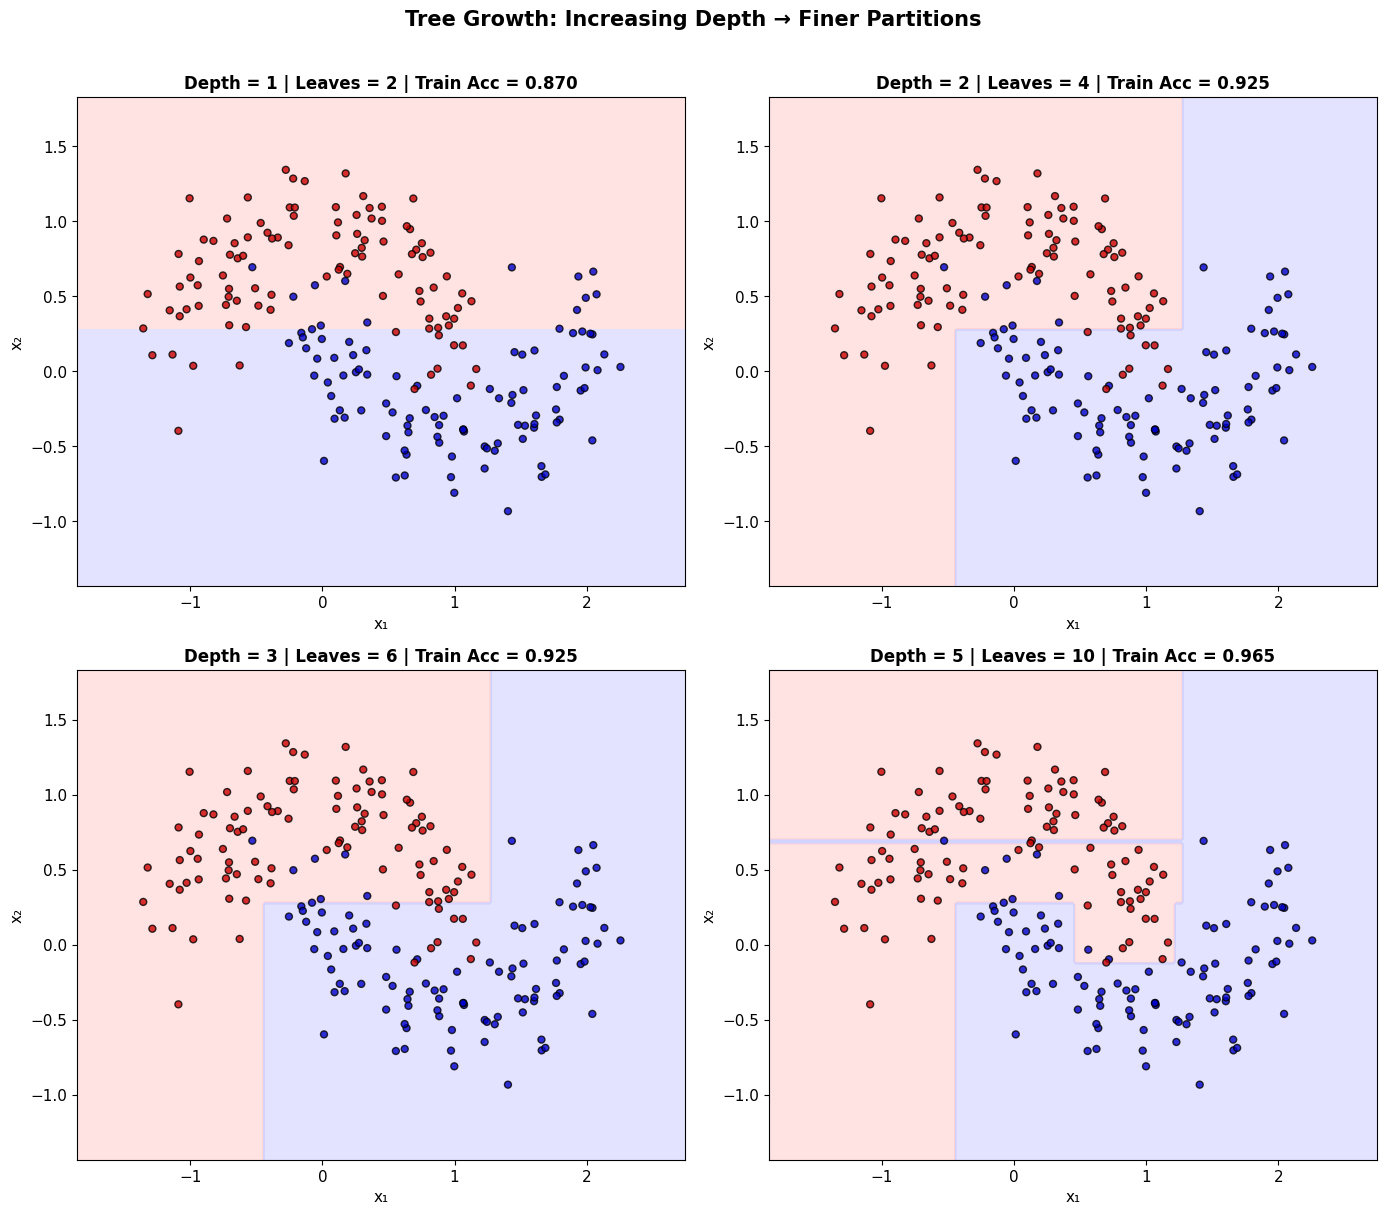

In [ ]:
# Visualize how a tree grows incrementally (depth 1, 2, 3, 4)
X_demo, y_demo = make_moons(n_samples=200, noise=0.2, random_state=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

h = 0.02
x_min, x_max = X_demo[:, 0].min() - 0.5, X_demo[:, 0].max() + 0.5
y_min, y_max = X_demo[:, 1].min() - 0.5, X_demo[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

cmap_light = ListedColormap(['#FFD1D1', '#D1D1FF'])
cmap_bold = ListedColormap(['#CC0000', '#0000CC'])

for i, depth in enumerate([1, 2, 3, 5]):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_demo, y_demo)
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    axes[i].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    axes[i].scatter(X_demo[:, 0], X_demo[:, 1], c=y_demo, cmap=cmap_bold,
                    edgecolors='k', s=25, alpha=0.8)
    acc = tree.score(X_demo, y_demo)
    axes[i].set_title(f'Depth = {depth} | Leaves = {tree.get_n_leaves()} | '
                      f'Train Acc = {acc:.3f}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('x₁')
    axes[i].set_ylabel('x₂')

plt.suptitle('Tree Growth: Increasing Depth → Finer Partitions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4. Splitting Criteria for Regression

For regression trees, the goal at each node is to find the split that **minimizes the variance** (or equivalently, the **Mean Squared Error**) within the resulting child nodes.

### Impurity Measure: MSE (Variance)

For a node $m$ with samples $D_m$:

$$\text{MSE}(m) = \frac{1}{|D_m|} \sum_{i \in D_m} (y_i - \bar{y}_m)^2$$

where $\bar{y}_m = \frac{1}{|D_m|} \sum_{i \in D_m} y_i$ is the mean target in node $m$.

### Weighted Impurity Reduction

When splitting node $m$ into children $m_L$ and $m_R$:

$$\Delta \text{MSE} = \text{MSE}(m) - \left[ \frac{|D_{m_L}|}{|D_m|} \text{MSE}(m_L) + \frac{|D_{m_R}|}{|D_m|} \text{MSE}(m_R) \right]$$

CART selects the feature $j$ and threshold $t$ that **maximize** $\Delta\text{MSE}$.

### Alternative: MAE (Mean Absolute Error)

$$\text{MAE}(m) = \frac{1}{|D_m|} \sum_{i \in D_m} |y_i - \tilde{y}_m|$$

where $\tilde{y}_m$ is the **median**. More robust to outliers but harder to optimize.


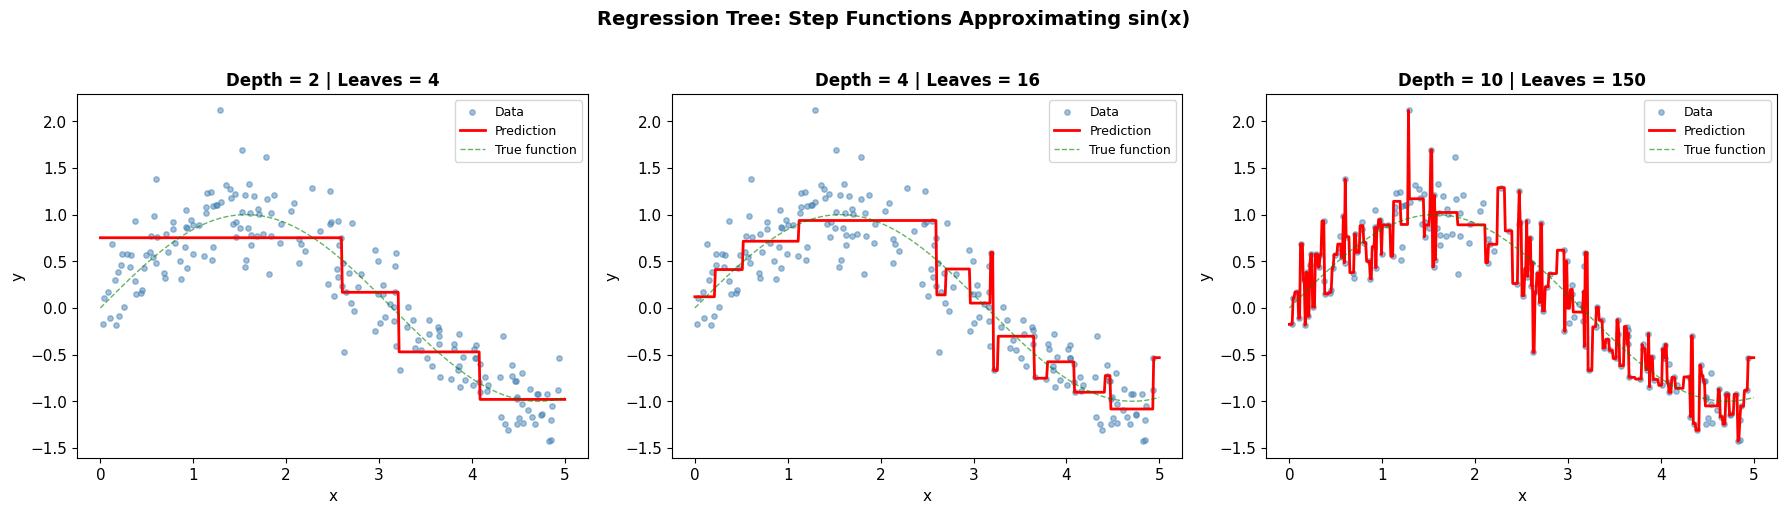

In [ ]:
# Demo: Regression tree on a noisy sine curve
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(200, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + 0.3 * np.random.randn(200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, depth in enumerate([2, 4, 10]):
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg.fit(X_reg, y_reg)

    X_test = np.linspace(0, 5, 500).reshape(-1, 1)
    y_pred = reg.predict(X_test)

    axes[i].scatter(X_reg, y_reg, s=15, alpha=0.5, c='steelblue', label='Data')
    axes[i].plot(X_test, y_pred, color='red', linewidth=2, label='Prediction')
    axes[i].plot(X_test, np.sin(X_test), color='green', linewidth=1,
                 linestyle='--', alpha=0.6, label='True function')
    axes[i].set_title(f'Depth = {depth} | Leaves = {reg.get_n_leaves()}',
                      fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')

plt.suptitle('Regression Tree: Step Functions Approximating sin(x)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Parent MSE: 5.8550 (mean = 5.70)

 Threshold |  Left Mean | Right Mean |   Left MSE |  Right MSE |   Weighted |  Reduction
------------------------------------------------------------------------------------------
       1.5 |      2.100 |      6.214 |     0.0000 |     4.5755 |     4.0036 |     1.8514
       2.5 |      2.000 |      6.933 |     0.0100 |     1.7189 |     1.2917 |     4.5633
       3.5 |      3.000 |      7.320 |     2.0067 |     1.1656 |     1.4810 |     4.3740
       4.5 |      3.550 |      7.850 |     2.4125 |     0.0525 |     1.2325 |     4.6225
       5.5 |      4.440 |      7.800 |     5.0984 |     0.0600 |     3.2090 |     2.6460
       6.5 |      5.000 |      7.800 |     5.8167 |     0.0900 |     4.3850 |     1.4700
       7.5 |      5.357 |      8.100 |     5.7510 |     0.0000 |     5.0321 |     0.8229

★ Best split: x ≤ 4.5 (reduction = 4.6225)


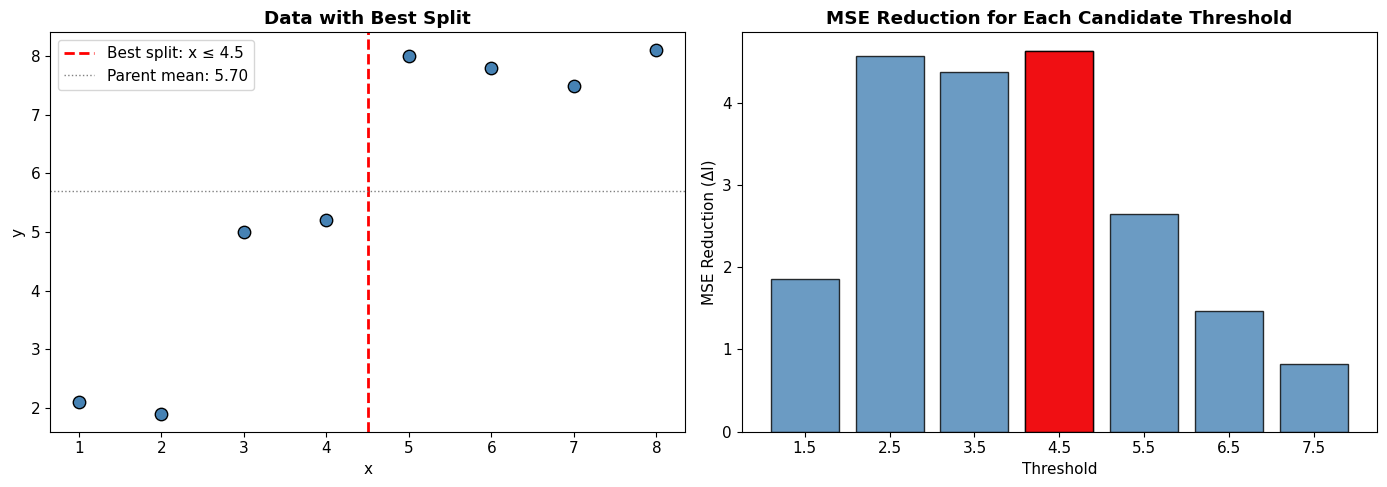

In [ ]:
# Manual computation of MSE split — illustrating how the best split is found
np.random.seed(42)
x_simple = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
y_simple = np.array([2.1, 1.9, 5.0, 5.2, 8.0, 7.8, 7.5, 8.1])

# Evaluate all candidate thresholds
thresholds = []
mse_reductions = []
parent_mse = np.var(y_simple) * len(y_simple) / len(y_simple)  # population variance

print(f"Parent MSE: {parent_mse:.4f} (mean = {np.mean(y_simple):.2f})\n")
print(f"{'Threshold':>10} | {'Left Mean':>10} | {'Right Mean':>10} | {'Left MSE':>10} | {'Right MSE':>10} | {'Weighted':>10} | {'Reduction':>10}")
print("-" * 90)

sorted_x = np.sort(np.unique(x_simple))
for i in range(len(sorted_x) - 1):
    t = (sorted_x[i] + sorted_x[i+1]) / 2.0
    left_mask = x_simple <= t
    right_mask = ~left_mask

    y_left = y_simple[left_mask]
    y_right = y_simple[right_mask]

    mse_left = np.mean((y_left - np.mean(y_left))**2)
    mse_right = np.mean((y_right - np.mean(y_right))**2)

    n_l, n_r = len(y_left), len(y_right)
    weighted = (n_l * mse_left + n_r * mse_right) / len(y_simple)
    reduction = parent_mse - weighted

    thresholds.append(t)
    mse_reductions.append(reduction)

    print(f"{t:>10.1f} | {np.mean(y_left):>10.3f} | {np.mean(y_right):>10.3f} | "
          f"{mse_left:>10.4f} | {mse_right:>10.4f} | {weighted:>10.4f} | {reduction:>10.4f}")

best_idx = np.argmax(mse_reductions)
print(f"\n★ Best split: x ≤ {thresholds[best_idx]:.1f} (reduction = {mse_reductions[best_idx]:.4f})")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(x_simple, y_simple, s=80, c='steelblue', edgecolors='k', zorder=5)
ax1.axvline(thresholds[best_idx], color='red', linewidth=2, linestyle='--', label=f'Best split: x ≤ {thresholds[best_idx]:.1f}')
ax1.axhline(np.mean(y_simple), color='gray', linewidth=1, linestyle=':', label=f'Parent mean: {np.mean(y_simple):.2f}')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Data with Best Split', fontweight='bold')
ax1.legend()

ax2.bar(range(len(thresholds)), mse_reductions, color='steelblue', edgecolor='k', alpha=0.8)
ax2.bar(best_idx, mse_reductions[best_idx], color='red', edgecolor='k', alpha=0.9)
ax2.set_xticks(range(len(thresholds)))
ax2.set_xticklabels([f'{t:.1f}' for t in thresholds])
ax2.set_xlabel('Threshold')
ax2.set_ylabel('MSE Reduction (ΔI)')
ax2.set_title('MSE Reduction for Each Candidate Threshold', fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Splitting Criteria for Classification

For classification, CART uses **Gini Impurity** by default. Other options include **Entropy** (Information Gain) and **Misclassification Error**.

### Gini Impurity

$$\text{Gini}(m) = 1 - \sum_{k=1}^{K} p_{mk}^2$$

where $p_{mk}$ is the proportion of class $k$ in node $m$. Ranges from 0 (pure) to $1 - 1/K$ (maximum impurity).

### Entropy (Information Gain)

$$\text{Entropy}(m) = - \sum_{k=1}^{K} p_{mk} \log_2(p_{mk})$$

Ranges from 0 (pure) to $\log_2(K)$.

### Misclassification Error

$$\text{Error}(m) = 1 - \max_k(p_{mk})$$

**Not used for tree growing** (not strictly concave — doesn't reward purer splits as much), but used in pruning.

### Comparison
- **Gini** and **Entropy** are very similar in practice (produce identical trees ~99% of the time).
- **Gini** is slightly faster (no logarithm).
- **Entropy** tends to produce slightly more balanced trees.
- **Misclassification Error** is piecewise linear — insensitive to changes in class probability at the ends.


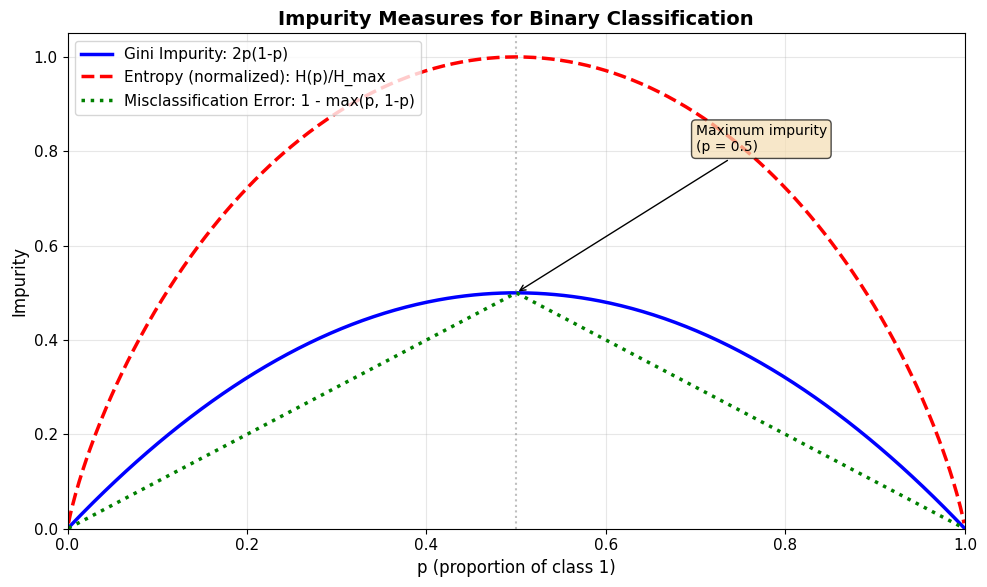

In [ ]:
# Visualize the three impurity measures for binary classification
p = np.linspace(0.001, 0.999, 500)

gini = 2 * p * (1 - p)  # Gini for binary case: 1 - p^2 - (1-p)^2 = 2p(1-p)
entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
misclass = 1 - np.maximum(p, 1 - p)

# Normalize entropy to [0, 1] for visual comparison
entropy_norm = entropy / np.max(entropy)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p, gini, 'b-', linewidth=2.5, label='Gini Impurity: 2p(1-p)')
ax.plot(p, entropy_norm, 'r--', linewidth=2.5, label='Entropy (normalized): H(p)/H_max')
ax.plot(p, misclass, 'g:', linewidth=2.5, label='Misclassification Error: 1 - max(p, 1-p)')

ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('p (proportion of class 1)', fontsize=12)
ax.set_ylabel('Impurity', fontsize=12)
ax.set_title('Impurity Measures for Binary Classification', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

# Annotate key points
ax.annotate('Maximum impurity\n(p = 0.5)', xy=(0.5, 0.5), xytext=(0.7, 0.8),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()


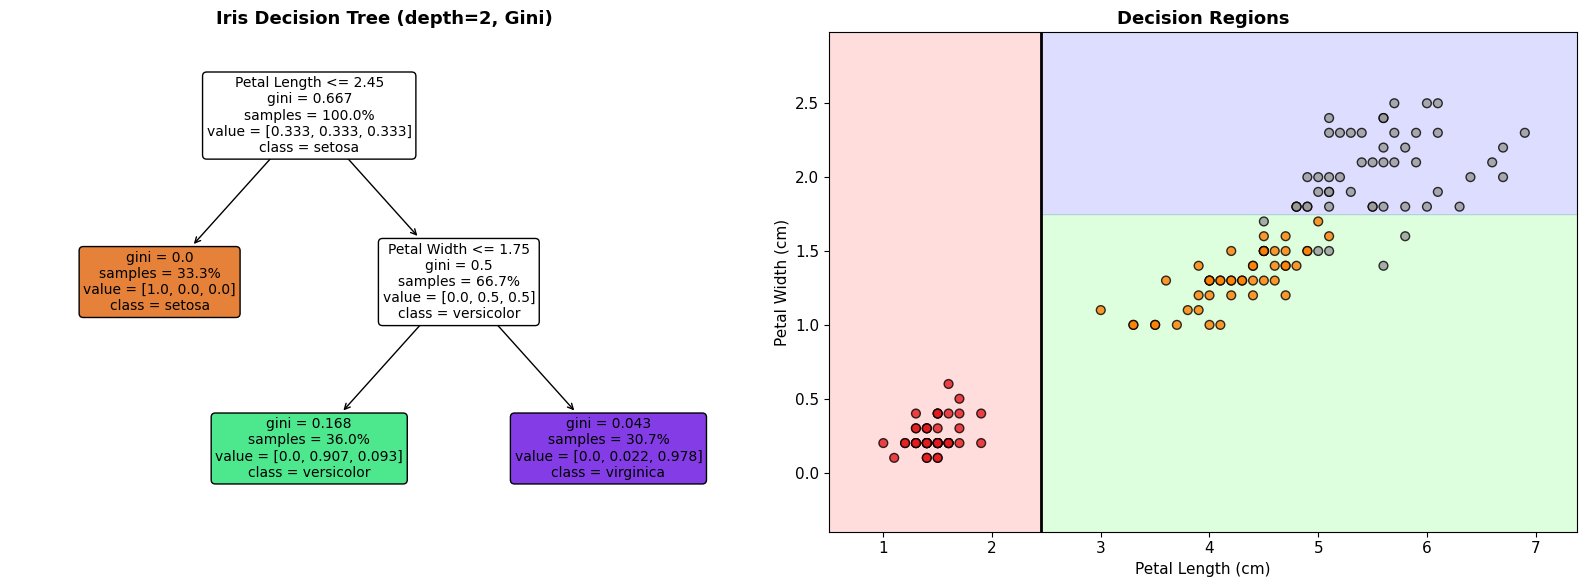

=== Manual Gini Computation: Root Split ===

Feature: petal length (cm), Threshold: 2.45

Left (PL ≤ thresh): counts=[50  0  0], proportions=[1. 0. 0.], Gini=0.0000
Right (PL > thresh): counts=[ 0 50 50], proportions=[0.  0.5 0.5], Gini=0.5000

Parent Gini: 0.6667
Weighted Child Gini: 0.3333
Gini Reduction: 0.3333


In [ ]:
# Manual Gini split computation on Iris (2 features for visualization)
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data[:, 2:4]  # petal length, petal width
y_iris = iris.target

# Fit a shallow tree
clf_iris = DecisionTreeClassifier(max_depth=2, criterion='gini', random_state=42)
clf_iris.fit(X_iris, y_iris)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot the tree
plot_tree(clf_iris, feature_names=['Petal Length', 'Petal Width'],
          class_names=iris.target_names, filled=True, rounded=True,
          fontsize=10, ax=ax1, proportion=True)
ax1.set_title('Iris Decision Tree (depth=2, Gini)', fontsize=13, fontweight='bold')

# Decision boundary
h = 0.02
x_min, x_max = X_iris[:, 0].min() - 0.5, X_iris[:, 0].max() + 0.5
y_min, y_max = X_iris[:, 1].min() - 0.5, X_iris[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = clf_iris.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap3 = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
ax2.contourf(xx, yy, Z, cmap=cmap3, alpha=0.4)
scatter = ax2.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, cmap='Set1',
                      edgecolors='k', s=40, alpha=0.8)
ax2.set_xlabel('Petal Length (cm)')
ax2.set_ylabel('Petal Width (cm)')
ax2.set_title('Decision Regions', fontsize=13, fontweight='bold')

# Draw the split lines
tree = clf_iris.tree_
# Root split
ax2.axvline(tree.threshold[0], color='black', linewidth=2, linestyle='-', label=f'Root: PL ≤ {tree.threshold[0]:.2f}')

plt.tight_layout()
plt.show()

# Manual Gini computation for the root split
print("=== Manual Gini Computation: Root Split ===\n")
threshold = tree.threshold[0]
feature_idx = tree.feature[0]
print(f"Feature: {iris.feature_names[feature_idx+2]}, Threshold: {threshold:.2f}\n")

left_mask = X_iris[:, 0] <= threshold
right_mask = ~left_mask

for name, mask in [("Left (PL ≤ thresh)", left_mask), ("Right (PL > thresh)", right_mask)]:
    counts = np.bincount(y_iris[mask], minlength=3)
    props = counts / counts.sum()
    gini = 1 - np.sum(props**2)
    print(f"{name}: counts={counts}, proportions={np.round(props, 3)}, Gini={gini:.4f}")

# Parent Gini
parent_counts = np.bincount(y_iris, minlength=3)
parent_props = parent_counts / parent_counts.sum()
parent_gini = 1 - np.sum(parent_props**2)
n = len(y_iris)
n_l = left_mask.sum()
n_r = right_mask.sum()
weighted_child_gini = (n_l/n) * (1 - np.sum((np.bincount(y_iris[left_mask], minlength=3)/n_l)**2)) + \
                      (n_r/n) * (1 - np.sum((np.bincount(y_iris[right_mask], minlength=3)/n_r)**2))
print(f"\nParent Gini: {parent_gini:.4f}")
print(f"Weighted Child Gini: {weighted_child_gini:.4f}")
print(f"Gini Reduction: {parent_gini - weighted_child_gini:.4f}")


### 5.1 Complete Worked Example: Gini & Entropy on the Iris Dataset

To build a solid intuition for how CART selects splits, let's walk through the **full computation** of both Gini impurity and Entropy for the Iris dataset — step by step, by hand (verified with code).

We will:
1. Compute the **parent impurity** (before any split) using both Gini and Entropy.
2. Evaluate **every candidate split** on petal length (the feature the tree selects first).
3. Compute the **impurity reduction** for each candidate and confirm the greedy best split.
4. Compare Gini vs Entropy rankings.

#### The Iris Dataset Recap

| Class | Name | Count |
|:------|:-----|------:|
| 0 | Setosa | 50 |
| 1 | Versicolor | 50 |
| 2 | Virginica | 50 |

**Total:** 150 samples, perfectly balanced (each class has probability 1/3).

---

#### Step 1: Parent Node Impurity

**Gini Impurity (Parent):**

$$\text{Gini}(\text{root}) = 1 - \sum_{k=0}^{2} p_k^2 = 1 - \left[\left(\frac{50}{150}\right)^2 + \left(\frac{50}{150}\right)^2 + \left(\frac{50}{150}\right)^2\right]$$

$$= 1 - \left[\frac{1}{9} + \frac{1}{9} + \frac{1}{9}\right] = 1 - \frac{3}{9} = 1 - \frac{1}{3} = 0.6667$$

**Entropy (Parent):**

$$H(\text{root}) = -\sum_{k=0}^{2} p_k \log_2 p_k = -3 \times \left(\frac{1}{3} \log_2 \frac{1}{3}\right)$$

$$= -3 \times \left(\frac{1}{3} \times (-1.585)\right) = -3 \times (-0.5283) = 1.585 \text{ bits}$$

Note: Maximum entropy for 3 classes is $\log_2 3 = 1.585$ bits, which makes sense — the parent is maximally uncertain.

---

#### Step 2: Evaluate Candidate Splits on Petal Length

Petal length is the first feature CART selects. Let's examine several candidate thresholds and compute the full impurity reduction for each.


In [ ]:
# ============================================================
# COMPLETE WORKED EXAMPLE: Gini & Entropy on Iris
# ============================================================

from sklearn.datasets import load_iris
import numpy as np
import pandas as pd

iris = load_iris()
X_iris_full = iris.data
y_iris_full = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Focus on Petal Length (feature index 2) — the feature CART picks first
petal_length = X_iris_full[:, 2]

# ──────────────────────────────────────────────────────────────
# STEP 1: Parent Node Impurity
# ──────────────────────────────────────────────────────────────
n_total = len(y_iris_full)
parent_counts = np.bincount(y_iris_full)
parent_props = parent_counts / n_total

parent_gini = 1 - np.sum(parent_props ** 2)
parent_entropy = -np.sum(parent_props * np.log2(parent_props))

print("=" * 70)
print("STEP 1: PARENT NODE (Root — all 150 samples)")
print("=" * 70)
print(f"  Class distribution: {dict(zip(class_names, parent_counts))}")
print(f"  Proportions:        {dict(zip(class_names, np.round(parent_props, 4)))}")
print()
print(f"  Gini = 1 - (p₀² + p₁² + p₂²)")
print(f"       = 1 - ({parent_props[0]:.4f}² + {parent_props[1]:.4f}² + {parent_props[2]:.4f}²)")
print(f"       = 1 - ({parent_props[0]**2:.4f} + {parent_props[1]**2:.4f} + {parent_props[2]**2:.4f})")
print(f"       = 1 - {np.sum(parent_props**2):.4f}")
print(f"       = {parent_gini:.4f}")
print()
print(f"  Entropy = -(p₀·log₂p₀ + p₁·log₂p₁ + p₂·log₂p₂)")
print(f"          = -({parent_props[0]:.4f}×{np.log2(parent_props[0]):.4f} + "
      f"{parent_props[1]:.4f}×{np.log2(parent_props[1]):.4f} + "
      f"{parent_props[2]:.4f}×{np.log2(parent_props[2]):.4f})")
print(f"          = -({parent_props[0]*np.log2(parent_props[0]):.4f} + "
      f"{parent_props[1]*np.log2(parent_props[1]):.4f} + "
      f"{parent_props[2]*np.log2(parent_props[2]):.4f})")
print(f"          = {parent_entropy:.4f} bits")
print(f"          (Maximum for 3 classes: log₂(3) = {np.log2(3):.4f} bits ✓)")


STEP 1: PARENT NODE (Root — all 150 samples)
  Class distribution: {'setosa': 50, 'versicolor': 50, 'virginica': 50}
  Proportions:        {'setosa': 0.3333, 'versicolor': 0.3333, 'virginica': 0.3333}

  Gini = 1 - (p₀² + p₁² + p₂²)
       = 1 - (0.3333² + 0.3333² + 0.3333²)
       = 1 - (0.1111 + 0.1111 + 0.1111)
       = 1 - 0.3333
       = 0.6667

  Entropy = -(p₀·log₂p₀ + p₁·log₂p₁ + p₂·log₂p₂)
          = -(0.3333×-1.5850 + 0.3333×-1.5850 + 0.3333×-1.5850)
          = -(-0.5283 + -0.5283 + -0.5283)
          = 1.5850 bits
          (Maximum for 3 classes: log₂(3) = 1.5850 bits ✓)


#### Step 2–3: Evaluate All Candidate Splits

For each candidate threshold $t$ on petal length, we split the data into:
- **Left child:** samples where petal length $\leq t$
- **Right child:** samples where petal length $> t$

Then we compute:

$$\text{Weighted Gini} = \frac{n_L}{n} \cdot \text{Gini}(L) + \frac{n_R}{n} \cdot \text{Gini}(R)$$

$$\text{Gini Reduction} = \text{Gini}(\text{parent}) - \text{Weighted Gini}$$

And equivalently for Entropy (which gives **Information Gain**):

$$\text{Information Gain} = H(\text{parent}) - \frac{n_L}{n} H(L) - \frac{n_R}{n} H(R)$$

Let's compute this for **every unique threshold** and find the best one.


In [ ]:
# ──────────────────────────────────────────────────────────────
# STEP 2–3: Evaluate ALL candidate splits on Petal Length
# ──────────────────────────────────────────────────────────────

def compute_gini(y):
    """Compute Gini impurity."""
    counts = np.bincount(y, minlength=3)
    props = counts / counts.sum()
    return 1 - np.sum(props ** 2)

def compute_entropy(y):
    """Compute entropy in bits."""
    counts = np.bincount(y, minlength=3)
    props = counts / counts.sum()
    props = props[props > 0]  # avoid log(0)
    return -np.sum(props * np.log2(props))

# Get sorted unique values and candidate midpoints
sorted_unique = np.sort(np.unique(petal_length))
candidate_thresholds = (sorted_unique[:-1] + sorted_unique[1:]) / 2.0

print(f"Petal Length range: [{sorted_unique.min():.1f}, {sorted_unique.max():.1f}]")
print(f"Number of unique values: {len(sorted_unique)}")
print(f"Number of candidate thresholds: {len(candidate_thresholds)}")
print()

# Compute impurity reduction for every threshold
results = []
for t in candidate_thresholds:
    left_mask = petal_length <= t
    right_mask = ~left_mask

    y_left = y_iris_full[left_mask]
    y_right = y_iris_full[right_mask]

    n_l, n_r = len(y_left), len(y_right)

    gini_l = compute_gini(y_left)
    gini_r = compute_gini(y_right)
    weighted_gini = (n_l * gini_l + n_r * gini_r) / n_total
    gini_reduction = parent_gini - weighted_gini

    entropy_l = compute_entropy(y_left)
    entropy_r = compute_entropy(y_right)
    weighted_entropy = (n_l * entropy_l + n_r * entropy_r) / n_total
    info_gain = parent_entropy - weighted_entropy

    left_counts = np.bincount(y_left, minlength=3)
    right_counts = np.bincount(y_right, minlength=3)

    results.append({
        'threshold': t,
        'n_left': n_l, 'n_right': n_r,
        'left_dist': f"[{left_counts[0]},{left_counts[1]},{left_counts[2]}]",
        'right_dist': f"[{right_counts[0]},{right_counts[1]},{right_counts[2]}]",
        'gini_left': gini_l, 'gini_right': gini_r,
        'weighted_gini': weighted_gini, 'gini_reduction': gini_reduction,
        'entropy_left': entropy_l, 'entropy_right': entropy_r,
        'weighted_entropy': weighted_entropy, 'info_gain': info_gain
    })

df_results = pd.DataFrame(results)

# Show the full table
print("=" * 120)
print("COMPLETE SPLIT EVALUATION TABLE — Petal Length (all candidate thresholds)")
print("=" * 120)
print(f"{'Thresh':>7} | {'nL':>3} {'nR':>3} | {'Left Dist':>12} {'Right Dist':>12} | "
      f"{'Gini_L':>7} {'Gini_R':>7} {'W.Gini':>7} {'ΔGini':>7} | "
      f"{'H_L':>7} {'H_R':>7} {'W.H':>7} {'IG':>7}")
print("-" * 120)

for _, row in df_results.iterrows():
    print(f"{row['threshold']:>7.2f} | {row['n_left']:>3.0f} {row['n_right']:>3.0f} | "
          f"{row['left_dist']:>12} {row['right_dist']:>12} | "
          f"{row['gini_left']:>7.4f} {row['gini_right']:>7.4f} {row['weighted_gini']:>7.4f} {row['gini_reduction']:>7.4f} | "
          f"{row['entropy_left']:>7.4f} {row['entropy_right']:>7.4f} {row['weighted_entropy']:>7.4f} {row['info_gain']:>7.4f}")

# Highlight best
best_gini_idx = df_results['gini_reduction'].idxmax()
best_ig_idx = df_results['info_gain'].idxmax()
print()
print(f"★ Best split (Gini):    threshold = {df_results.loc[best_gini_idx, 'threshold']:.2f}, "
      f"Gini reduction = {df_results.loc[best_gini_idx, 'gini_reduction']:.4f}")
print(f"★ Best split (Entropy): threshold = {df_results.loc[best_ig_idx, 'threshold']:.2f}, "
      f"Info Gain = {df_results.loc[best_ig_idx, 'info_gain']:.4f}")
print(f"\n{'✅ Gini and Entropy AGREE on the best split!' if best_gini_idx == best_ig_idx else '⚠️ Gini and Entropy DISAGREE!'}")


Petal Length range: [1.0, 6.9]
Number of unique values: 43
Number of candidate thresholds: 42

COMPLETE SPLIT EVALUATION TABLE — Petal Length (all candidate thresholds)
 Thresh |  nL  nR |    Left Dist   Right Dist |  Gini_L  Gini_R  W.Gini   ΔGini |     H_L     H_R     W.H      IG
------------------------------------------------------------------------------------------------------------------------
   1.05 |   1 149 |      [1,0,0]   [49,50,50] |  0.0000  0.6666  0.6622  0.0045 | -0.0000  1.5849  1.5743  0.0106
   1.15 |   2 148 |      [2,0,0]   [48,50,50] |  0.0000  0.6665  0.6577  0.0090 | -0.0000  1.5847  1.5636  0.0214
   1.25 |   4 146 |      [4,0,0]   [46,50,50] |  0.0000  0.6662  0.6484  0.0183 | -0.0000  1.5839  1.5416  0.0433
   1.35 |  11 139 |     [11,0,0]   [39,50,50] |  0.0000  0.6625  0.6139  0.0528 | -0.0000  1.5757  1.4601  0.1249
   1.45 |  24 126 |     [24,0,0]   [26,50,50] |  0.0000  0.6425  0.5397  0.1270 | -0.0000  1.5281  1.2836  0.3014
   1.55 |  37 113 |     [3

#### Step 4: Detailed Hand Computation for the Best Split

Let's verify the best split ($\text{petal length} \leq 2.45$) by showing every arithmetic step — exactly as you would write on an exam.


In [ ]:
# ──────────────────────────────────────────────────────────────
# STEP 4: DETAILED HAND COMPUTATION for the best split
# ──────────────────────────────────────────────────────────────

best_t = df_results.loc[best_gini_idx, 'threshold']
left_mask = petal_length <= best_t
right_mask = ~left_mask

y_left = y_iris_full[left_mask]
y_right = y_iris_full[right_mask]

left_counts = np.bincount(y_left, minlength=3)
right_counts = np.bincount(y_right, minlength=3)

n_l, n_r = len(y_left), len(y_right)
left_props = left_counts / n_l
right_props = right_counts / n_r

print("=" * 70)
print(f"DETAILED COMPUTATION: Split at Petal Length ≤ {best_t:.2f}")
print("=" * 70)

# ── LEFT CHILD ──
print(f"\n── LEFT CHILD (Petal Length ≤ {best_t:.2f}) ──")
print(f"   Samples: {n_l}")
print(f"   Setosa: {left_counts[0]}, Versicolor: {left_counts[1]}, Virginica: {left_counts[2]}")
print(f"   Proportions: p₀ = {left_counts[0]}/{n_l} = {left_props[0]:.4f}, "
      f"p₁ = {left_counts[1]}/{n_l} = {left_props[1]:.4f}, "
      f"p₂ = {left_counts[2]}/{n_l} = {left_props[2]:.4f}")
print()

gini_l = 1 - np.sum(left_props**2)
print(f"   Gini(Left) = 1 - ({left_props[0]:.4f}² + {left_props[1]:.4f}² + {left_props[2]:.4f}²)")
print(f"              = 1 - ({left_props[0]**2:.4f} + {left_props[1]**2:.4f} + {left_props[2]**2:.4f})")
print(f"              = 1 - {np.sum(left_props**2):.4f}")
print(f"              = {gini_l:.4f}")

# Handle entropy with possible 0
left_props_nz = left_props[left_props > 0]
entropy_l = -np.sum(left_props_nz * np.log2(left_props_nz))
print()
if left_counts[1] == 0 and left_counts[2] == 0:
    print(f"   Entropy(Left) = -(1.0 × log₂(1.0) + 0 + 0)")
    print(f"                 = -(1.0 × 0.0)")
    print(f"                 = {entropy_l:.4f} bits  (pure node!)")
else:
    terms = []
    for k in range(3):
        if left_props[k] > 0:
            terms.append(f"{left_props[k]:.4f}×log₂({left_props[k]:.4f})")
    print(f"   Entropy(Left) = -({' + '.join(terms)})")
    print(f"                 = {entropy_l:.4f} bits")

# ── RIGHT CHILD ──
print(f"\n── RIGHT CHILD (Petal Length > {best_t:.2f}) ──")
print(f"   Samples: {n_r}")
print(f"   Setosa: {right_counts[0]}, Versicolor: {right_counts[1]}, Virginica: {right_counts[2]}")
print(f"   Proportions: p₀ = {right_counts[0]}/{n_r} = {right_props[0]:.4f}, "
      f"p₁ = {right_counts[1]}/{n_r} = {right_props[1]:.4f}, "
      f"p₂ = {right_counts[2]}/{n_r} = {right_props[2]:.4f}")
print()

gini_r = 1 - np.sum(right_props**2)
print(f"   Gini(Right) = 1 - ({right_props[0]:.4f}² + {right_props[1]:.4f}² + {right_props[2]:.4f}²)")
print(f"               = 1 - ({right_props[0]**2:.4f} + {right_props[1]**2:.4f} + {right_props[2]**2:.4f})")
print(f"               = 1 - {np.sum(right_props**2):.4f}")
print(f"               = {gini_r:.4f}")

right_props_nz = right_props[right_props > 0]
entropy_r = -np.sum(right_props_nz * np.log2(right_props_nz))
print()
terms_r = []
for k in range(3):
    if right_props[k] > 0:
        terms_r.append(f"{right_props[k]:.4f}×log₂({right_props[k]:.4f})")
print(f"   Entropy(Right) = -({' + '.join(terms_r)})")
print(f"                  = {entropy_r:.4f} bits")

# ── WEIGHTED IMPURITY ──
print(f"\n── WEIGHTED IMPURITY & REDUCTION ──")
print(f"   Weight_L = n_L / n = {n_l}/{n_total} = {n_l/n_total:.4f}")
print(f"   Weight_R = n_R / n = {n_r}/{n_total} = {n_r/n_total:.4f}")
print()

w_gini = (n_l/n_total) * gini_l + (n_r/n_total) * gini_r
print(f"   Weighted Gini = ({n_l/n_total:.4f} × {gini_l:.4f}) + ({n_r/n_total:.4f} × {gini_r:.4f})")
print(f"                 = {(n_l/n_total)*gini_l:.4f} + {(n_r/n_total)*gini_r:.4f}")
print(f"                 = {w_gini:.4f}")
print(f"   Gini Reduction = {parent_gini:.4f} - {w_gini:.4f} = {parent_gini - w_gini:.4f}")
print()

w_entropy = (n_l/n_total) * entropy_l + (n_r/n_total) * entropy_r
print(f"   Weighted Entropy = ({n_l/n_total:.4f} × {entropy_l:.4f}) + ({n_r/n_total:.4f} × {entropy_r:.4f})")
print(f"                    = {(n_l/n_total)*entropy_l:.4f} + {(n_r/n_total)*entropy_r:.4f}")
print(f"                    = {w_entropy:.4f}")
print(f"   Information Gain = {parent_entropy:.4f} - {w_entropy:.4f} = {parent_entropy - w_entropy:.4f} bits")


DETAILED COMPUTATION: Split at Petal Length ≤ 2.45

── LEFT CHILD (Petal Length ≤ 2.45) ──
   Samples: 50
   Setosa: 50, Versicolor: 0, Virginica: 0
   Proportions: p₀ = 50/50 = 1.0000, p₁ = 0/50 = 0.0000, p₂ = 0/50 = 0.0000

   Gini(Left) = 1 - (1.0000² + 0.0000² + 0.0000²)
              = 1 - (1.0000 + 0.0000 + 0.0000)
              = 1 - 1.0000
              = 0.0000

   Entropy(Left) = -(1.0 × log₂(1.0) + 0 + 0)
                 = -(1.0 × 0.0)
                 = -0.0000 bits  (pure node!)

── RIGHT CHILD (Petal Length > 2.45) ──
   Samples: 100
   Setosa: 0, Versicolor: 50, Virginica: 50
   Proportions: p₀ = 0/100 = 0.0000, p₁ = 50/100 = 0.5000, p₂ = 50/100 = 0.5000

   Gini(Right) = 1 - (0.0000² + 0.5000² + 0.5000²)
               = 1 - (0.0000 + 0.2500 + 0.2500)
               = 1 - 0.5000
               = 0.5000

   Entropy(Right) = -(0.5000×log₂(0.5000) + 0.5000×log₂(0.5000))
                  = 1.0000 bits

── WEIGHTED IMPURITY & REDUCTION ──
   Weight_L = n_L / n = 50/150 = 0

#### Step 5: Visual Summary & Ranking Comparison

Let's visualize the Gini reduction and Information Gain across all thresholds, and check whether they rank splits the same way.


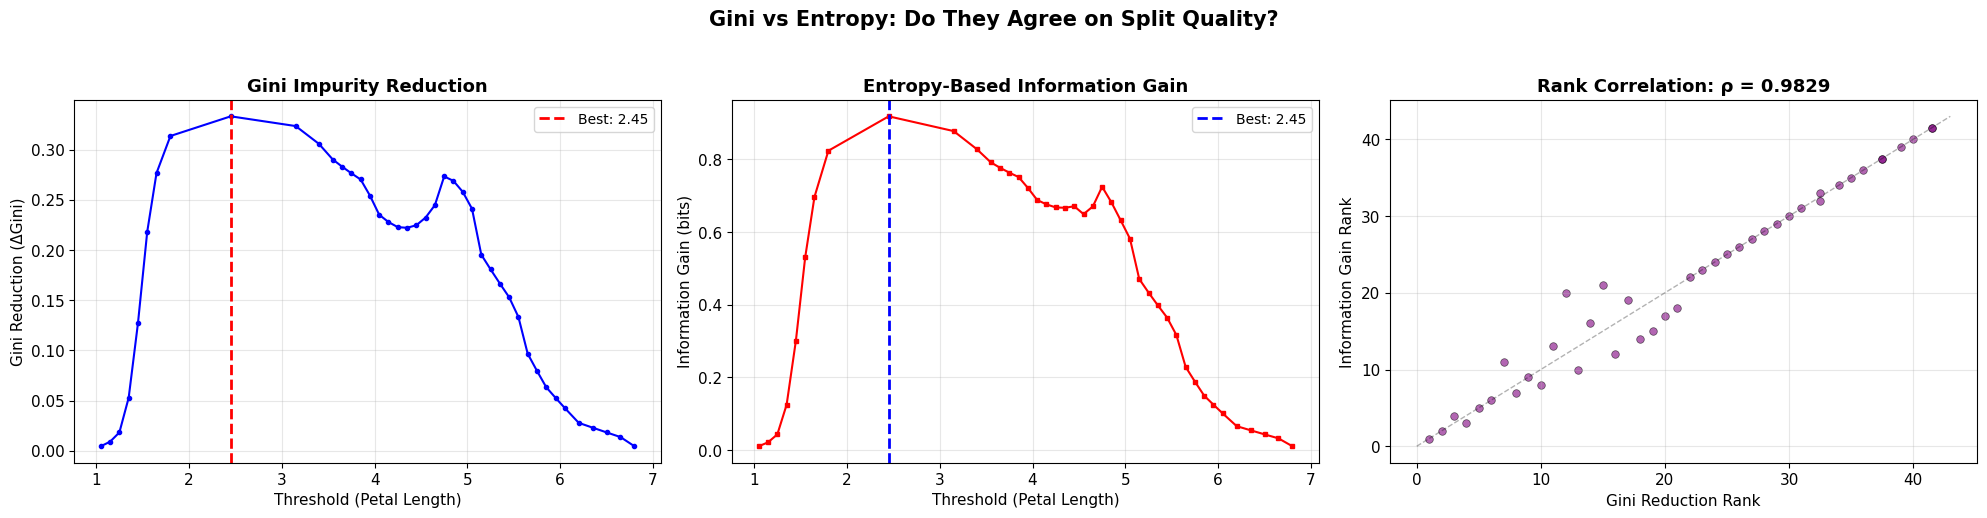

Spearman rank correlation between Gini and Entropy rankings: ρ = 0.9829 (p = 4.91e-31)

💡 Key Insight: Gini and Entropy rank nearly ALL candidate splits in the SAME order.
   The rank correlation is 0.9829 — almost perfect agreement.
   This is why the choice between Gini and Entropy rarely matters in practice.


In [ ]:
# ──────────────────────────────────────────────────────────────
# STEP 5: Visualization — Gini Reduction vs Information Gain
# ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Gini Reduction
axes[0].plot(df_results['threshold'], df_results['gini_reduction'], 'b-o', markersize=3, linewidth=1.5)
axes[0].axvline(df_results.loc[best_gini_idx, 'threshold'], color='red', linestyle='--', linewidth=2,
                label=f"Best: {df_results.loc[best_gini_idx, 'threshold']:.2f}")
axes[0].set_xlabel('Threshold (Petal Length)', fontsize=11)
axes[0].set_ylabel('Gini Reduction (ΔGini)', fontsize=11)
axes[0].set_title('Gini Impurity Reduction', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Panel 2: Information Gain
axes[1].plot(df_results['threshold'], df_results['info_gain'], 'r-s', markersize=3, linewidth=1.5)
axes[1].axvline(df_results.loc[best_ig_idx, 'threshold'], color='blue', linestyle='--', linewidth=2,
                label=f"Best: {df_results.loc[best_ig_idx, 'threshold']:.2f}")
axes[1].set_xlabel('Threshold (Petal Length)', fontsize=11)
axes[1].set_ylabel('Information Gain (bits)', fontsize=11)
axes[1].set_title('Entropy-Based Information Gain', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Panel 3: Rank Comparison
from scipy.stats import spearmanr
gini_ranks = df_results['gini_reduction'].rank(ascending=False)
ig_ranks = df_results['info_gain'].rank(ascending=False)
correlation, p_value = spearmanr(gini_ranks, ig_ranks)

axes[2].scatter(gini_ranks, ig_ranks, c='purple', alpha=0.6, s=30, edgecolors='k', linewidths=0.5)
axes[2].plot([0, len(gini_ranks)+1], [0, len(gini_ranks)+1], 'k--', alpha=0.3, linewidth=1)
axes[2].set_xlabel('Gini Reduction Rank', fontsize=11)
axes[2].set_ylabel('Information Gain Rank', fontsize=11)
axes[2].set_title(f'Rank Correlation: ρ = {correlation:.4f}', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Gini vs Entropy: Do They Agree on Split Quality?', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f"Spearman rank correlation between Gini and Entropy rankings: ρ = {correlation:.4f} (p = {p_value:.2e})")
print(f"\n💡 Key Insight: Gini and Entropy rank nearly ALL candidate splits in the SAME order.")
print(f"   The rank correlation is {correlation:.4f} — almost perfect agreement.")
print(f"   This is why the choice between Gini and Entropy rarely matters in practice.")


#### Summary: What We Just Computed

| Quantity | Formula | Value |
|:---------|:--------|------:|
| Parent Gini | $1 - \sum p_k^2$ | 0.6667 |
| Parent Entropy | $-\sum p_k \log_2 p_k$ | 1.5850 bits |
| Best Threshold | Petal Length ≤ 2.45 | — |
| Left Child | 50 Setosa, 0 others | Pure! |
| Right Child | 0 Setosa, 50 Versi., 50 Virg. | Gini = 0.5 |
| Gini Reduction | $0.6667 - 0.3333$ | **0.3333** |
| Information Gain | $1.585 - 0.667$ | **0.918 bits** |

**Why is this the best split?** Because petal length ≤ 2.45 perfectly separates Setosa from the other two classes. The left child is **completely pure** (Gini = 0, Entropy = 0), which is the best possible outcome for a single split. The remaining impurity is entirely in the right child, which still contains a mixture of Versicolor and Virginica — this will be resolved by subsequent splits.

---


## 6. Computational Aspects of Finding Splits

### Brute-Force Approach

At each node with $n$ samples and $p$ features:

1. For each feature $j \in \{1, ..., p\}$:
   - Sort the $n$ values of feature $j$: $O(n \log n)$
   - Evaluate at most $n - 1$ candidate thresholds (midpoints between consecutive sorted unique values)
   - For each threshold, compute the impurity reduction: $O(1)$ if done incrementally
2. Select the best (feature, threshold) pair.

### Complexity

| Step | Cost |
|:-----|:-----|
| Sorting all features | $O(p \cdot n \log n)$ |
| Evaluating all splits | $O(p \cdot n)$ |
| **Per node** | $O(p \cdot n \log n)$ |
| **Full tree (balanced)** | $O(p \cdot n \log^2 n)$ |
| **Full tree (worst case)** | $O(p \cdot n^2 \log n)$ |

### Optimization Tricks (used by scikit-learn)

1. **Pre-sorting** (SORT strategy): Sort features once, maintain sorted indices. Trade memory for speed.
2. **Best-first split** vs **depth-first**: scikit-learn uses depth-first by default but supports best-first via `max_leaf_nodes`.
3. **Incremental impurity computation**: When moving the threshold by one sample, update the split statistics in $O(1)$ instead of recomputing from scratch.
4. **Feature subsampling**: `max_features` parameter — consider only a random subset at each split (used in Random Forests).
5. **Min samples thresholds**: `min_samples_split` and `min_samples_leaf` to skip evaluation of tiny nodes.


Best threshold: 4.784
Best MSE reduction: 0.1733
Number of candidate splits evaluated: 19

💡 Key insight: Each threshold evaluation is O(1) — just update running sums!


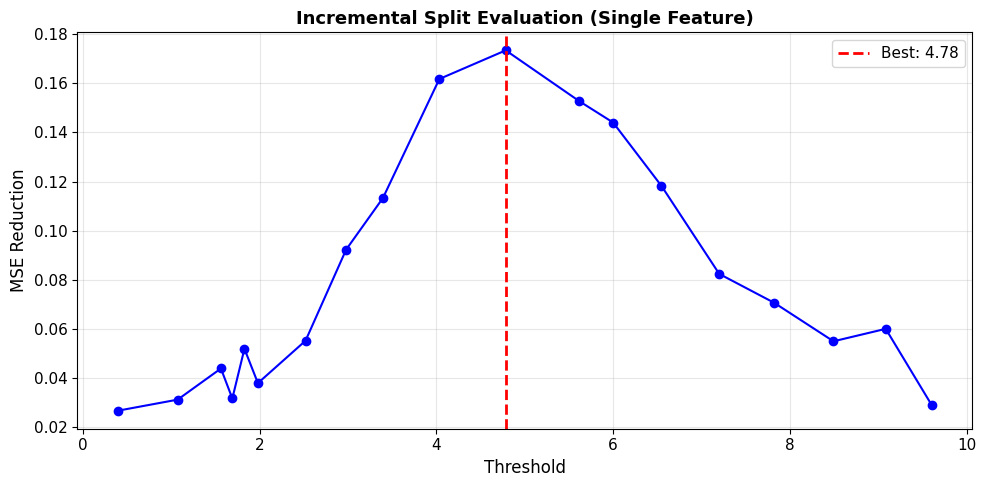

In [ ]:
# Demonstrate incremental impurity computation for efficiency
# This shows WHY we sort once and scan — O(n) per feature instead of O(n^2)

np.random.seed(42)
n = 20
x_feat = np.random.rand(n) * 10
y_target = (x_feat > 5).astype(float) + 0.3 * np.random.randn(n)

# Sort once
sort_idx = np.argsort(x_feat)
x_sorted = x_feat[sort_idx]
y_sorted = y_target[sort_idx]

# Incremental computation: maintain running sums
total_sum = np.sum(y_sorted)
total_sq_sum = np.sum(y_sorted**2)
total_n = len(y_sorted)

left_sum = 0.0
left_sq_sum = 0.0
left_n = 0

best_reduction = -np.inf
best_threshold = None

reductions = []
thresholds_list = []

for i in range(total_n - 1):
    # Move sample i from right to left
    left_sum += y_sorted[i]
    left_sq_sum += y_sorted[i]**2
    left_n += 1

    right_sum = total_sum - left_sum
    right_sq_sum = total_sq_sum - left_sq_sum
    right_n = total_n - left_n

    # Skip if same feature value (can't split between identical values)
    if x_sorted[i] == x_sorted[i + 1]:
        continue

    # MSE computation: Var = E[X^2] - E[X]^2
    left_mse = left_sq_sum / left_n - (left_sum / left_n)**2
    right_mse = right_sq_sum / right_n - (right_sum / right_n)**2
    parent_mse = total_sq_sum / total_n - (total_sum / total_n)**2

    weighted = (left_n * left_mse + right_n * right_mse) / total_n
    reduction = parent_mse - weighted

    threshold = (x_sorted[i] + x_sorted[i+1]) / 2
    thresholds_list.append(threshold)
    reductions.append(reduction)

    if reduction > best_reduction:
        best_reduction = reduction
        best_threshold = threshold

print(f"Best threshold: {best_threshold:.3f}")
print(f"Best MSE reduction: {best_reduction:.4f}")
print(f"Number of candidate splits evaluated: {len(reductions)}")
print(f"\n💡 Key insight: Each threshold evaluation is O(1) — just update running sums!")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_list, reductions, 'bo-', markersize=6, linewidth=1.5)
ax.axvline(best_threshold, color='red', linewidth=2, linestyle='--',
           label=f'Best: {best_threshold:.2f}')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('MSE Reduction', fontsize=12)
ax.set_title('Incremental Split Evaluation (Single Feature)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Stopping Criteria and Pruning

Without any constraints, CART will grow until every leaf is **pure** — this overfits badly. Two families of strategies prevent this:

### A. Pre-pruning (Stopping Criteria)

Stop splitting **during** tree growth. Scikit-learn parameters:

| Parameter | Description | Effect |
|:----------|:------------|:-------|
| `max_depth` | Maximum tree depth | Limits complexity directly |
| `min_samples_split` | Min samples to attempt a split | Prevents splitting tiny nodes |
| `min_samples_leaf` | Min samples in each leaf | Prevents tiny, noisy leaves |
| `max_leaf_nodes` | Maximum number of leaves | Controls model complexity |
| `min_impurity_decrease` | Min impurity reduction to split | Threshold for "worthwhile" splits |
| `max_features` | Features considered per split | Adds randomness, reduces variance |

### B. Post-pruning (Cost-Complexity Pruning)

Grow the full tree first, then **prune back** subtrees that don't improve generalization. CART uses **Minimal Cost-Complexity Pruning** (also called weakest-link pruning):

$$R_\alpha(T) = R(T) + \alpha \cdot |\widetilde{T}|$$

where:
- $R(T)$: Misclassification rate (or MSE) of tree $T$ on training data
- $|\widetilde{T}|$: Number of terminal (leaf) nodes
- $\alpha \geq 0$: Complexity parameter (penalty per leaf)

As $\alpha$ increases: more leaves are pruned → simpler tree. Select $\alpha^*$ via **cross-validation**.


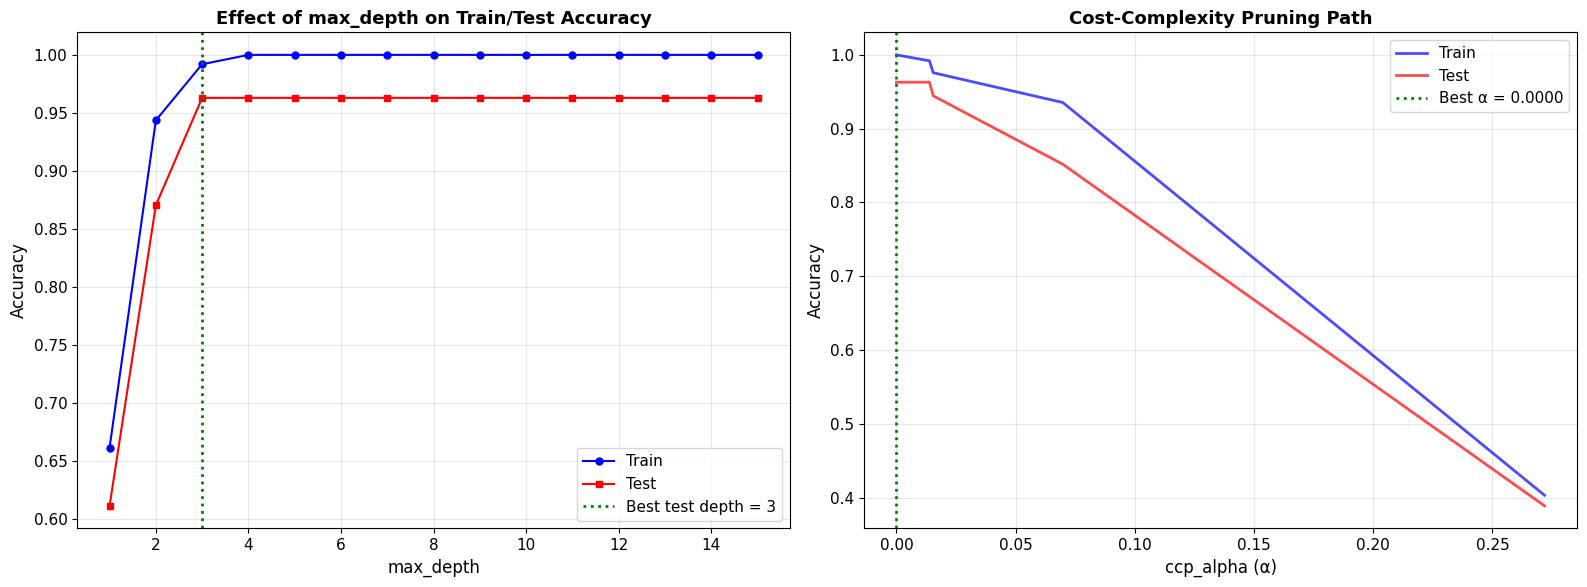

Full tree: 7 leaves, Train=1.000, Test=0.963
Best pruned: 7 leaves, Train=1.000, Test=0.963
Best alpha: 0.00000


In [ ]:
# Demonstrate the effect of pre-pruning parameters
from sklearn.datasets import load_wine

wine = load_wine()
X_w, y_w = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X_w, y_w, test_size=0.3, random_state=42)

# Vary max_depth
depths = range(1, 16)
train_scores = []
test_scores = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(depths, train_scores, 'b-o', label='Train', markersize=5)
ax1.plot(depths, test_scores, 'r-s', label='Test', markersize=5)
ax1.set_xlabel('max_depth', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Effect of max_depth on Train/Test Accuracy', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axvline(depths[np.argmax(test_scores)], color='green', linestyle=':', linewidth=2,
            label=f'Best test depth = {depths[np.argmax(test_scores)]}')
ax1.legend(fontsize=11)

# Cost-complexity pruning path
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

# Train trees for each alpha
pruned_train = []
pruned_test = []
n_leaves_list = []

for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    tree.fit(X_train, y_train)
    pruned_train.append(tree.score(X_train, y_train))
    pruned_test.append(tree.score(X_test, y_test))
    n_leaves_list.append(tree.get_n_leaves())

ax2.plot(ccp_alphas, pruned_train, 'b-', label='Train', alpha=0.7, linewidth=2)
ax2.plot(ccp_alphas, pruned_test, 'r-', label='Test', alpha=0.7, linewidth=2)
best_alpha_idx = np.argmax(pruned_test)
ax2.axvline(ccp_alphas[best_alpha_idx], color='green', linestyle=':', linewidth=2,
            label=f'Best α = {ccp_alphas[best_alpha_idx]:.4f}')
ax2.set_xlabel('ccp_alpha (α)', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Cost-Complexity Pruning Path', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Full tree: {full_tree.get_n_leaves()} leaves, "
      f"Train={full_tree.score(X_train, y_train):.3f}, "
      f"Test={full_tree.score(X_test, y_test):.3f}")
print(f"Best pruned: {n_leaves_list[best_alpha_idx]} leaves, "
      f"Train={pruned_train[best_alpha_idx]:.3f}, "
      f"Test={pruned_test[best_alpha_idx]:.3f}")
print(f"Best alpha: {ccp_alphas[best_alpha_idx]:.5f}")


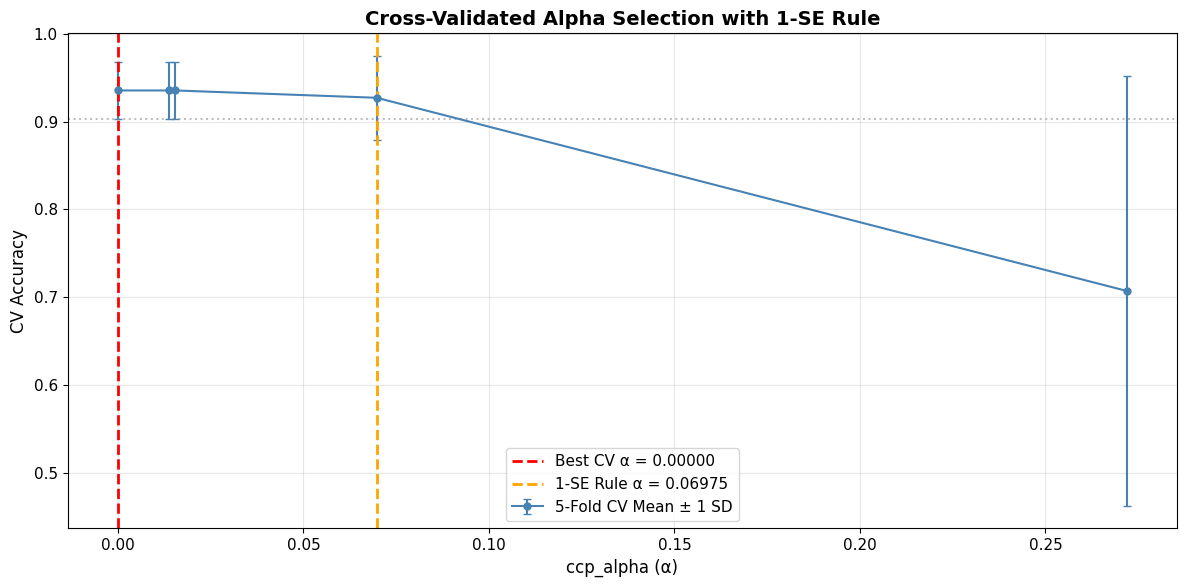

1-SE Rule Model: depth=2, leaves=3
Train Accuracy: 0.9355
Test Accuracy: 0.8519


In [ ]:
# Cross-validated selection of ccp_alpha
from sklearn.model_selection import cross_val_score

# Use a subset of alphas for speed
alpha_candidates = ccp_alphas[::max(1, len(ccp_alphas)//30)]  # Sample ~30 alphas

cv_means = []
cv_stds = []

for alpha in alpha_candidates:
    tree = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)

best_cv_idx = np.argmax(cv_means)
best_cv_alpha = alpha_candidates[best_cv_idx]

# 1-SE rule: pick the simplest model within 1 SE of the best
threshold = cv_means[best_cv_idx] - cv_stds[best_cv_idx]
one_se_idx = np.where(cv_means >= threshold)[0][-1]  # largest alpha (simplest) above threshold
one_se_alpha = alpha_candidates[one_se_idx]

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(alpha_candidates, cv_means, yerr=cv_stds, fmt='o-', capsize=3,
            color='steelblue', markersize=5, linewidth=1.5, label='5-Fold CV Mean ± 1 SD')
ax.axvline(best_cv_alpha, color='red', linestyle='--', linewidth=2,
           label=f'Best CV α = {best_cv_alpha:.5f}')
ax.axvline(one_se_alpha, color='orange', linestyle='--', linewidth=2,
           label=f'1-SE Rule α = {one_se_alpha:.5f}')
ax.axhline(threshold, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('ccp_alpha (α)', fontsize=12)
ax.set_ylabel('CV Accuracy', fontsize=12)
ax.set_title('Cross-Validated Alpha Selection with 1-SE Rule', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final model with 1-SE alpha
final_tree = DecisionTreeClassifier(ccp_alpha=one_se_alpha, random_state=42)
final_tree.fit(X_train, y_train)
print(f"1-SE Rule Model: depth={final_tree.get_depth()}, leaves={final_tree.get_n_leaves()}")
print(f"Train Accuracy: {final_tree.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {final_tree.score(X_test, y_test):.4f}")


## 7.5 Surrogate Splits in CART

### What Are Surrogate Splits?

One of the most elegant features of the original CART algorithm (Breiman et al., 1984) is the concept of **surrogate splits** — a mechanism for handling **missing values** without imputation.

> A **surrogate split** is an alternative splitting rule at a node that produces a partition as similar as possible to the primary (best) split, but uses a **different feature**.

#### The Core Idea

At each internal node, CART finds the best split (the "primary" split). It then searches for **surrogate splits** on other features that **mimic the same partition**. If a new sample arrives at this node with the primary feature missing, CART uses the best surrogate split instead.

#### Why Surrogates Work

Many real-world datasets have **correlated features**. If feature A is missing, a correlated feature B can often produce a nearly identical split. Surrogates exploit this correlation structure automatically.

#### How Surrogate Splits Are Found

For a primary split $s^*$ on feature $j$ at threshold $t$ that sends $n_L$ samples left and $n_R$ samples right:

1. For every other feature $j' \neq j$ and every threshold $t'$:
   - Compute the split $s'$: samples with $x_{j'} \leq t'$ go left, others go right.
   - Measure **predictive association**: what fraction of samples does $s'$ send to the **same child** as $s^*$?
   
2. The **predictive association** (concordance) of surrogate $s'$ with primary $s^*$ is:

$$\text{Concordance}(s', s^*) = \frac{\text{# samples sent to same side by both } s' \text{ and } s^*}{n}$$

3. Compare against the **naive rule** (always send to the majority side):

$$\text{Naive concordance} = \frac{\max(n_L, n_R)}{n}$$

4. A surrogate is useful only if its concordance **exceeds** the naive rule.

5. Rank all surrogates by concordance. The top surrogate is used first if the primary feature is missing; if that feature is also missing, use the second surrogate, and so on.

#### Surrogate Splits Also Reveal Feature Relationships

Beyond missing data handling, surrogates provide a **measure of variable association** — they tell you which features carry similar information. This is a form of unsupervised structure discovery embedded within a supervised algorithm.

---

> **Note:** Scikit-learn does NOT implement surrogate splits. It requires complete data (no missing values). To use surrogates in Python, you need libraries like `rpart` (R, via `rpy2`) or manual implementation. Below, we implement a simplified version to demonstrate the concept.


In [ ]:
# ============================================================
# SURROGATE SPLITS: Complete Example on Iris
# ============================================================
# We'll manually demonstrate how surrogate splits work at the
# root node of an Iris decision tree.

from sklearn.datasets import load_iris
import numpy as np
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# ──────────────────────────────────────────────────────────────
# Step 1: Identify the primary (best) split
# ──────────────────────────────────────────────────────────────
# From our earlier analysis, the best split at the root is:
#   Petal Length (feature 2) ≤ 2.45
# This sends 50 samples LEFT and 100 samples RIGHT.

primary_feature = 2  # petal length
primary_threshold = 2.45

primary_left = X[:, primary_feature] <= primary_threshold
primary_right = ~primary_left

n = len(y)
n_left = primary_left.sum()
n_right = primary_right.sum()

print("=" * 70)
print("PRIMARY SPLIT: Petal Length ≤ 2.45")
print("=" * 70)
print(f"  Left child:  {n_left} samples (all Setosa)")
print(f"  Right child: {n_right} samples (Versicolor + Virginica)")
print(f"  Naive rule:  always send RIGHT → concordance = {n_right}/{n} = {n_right/n:.4f}")
print()

# ──────────────────────────────────────────────────────────────
# Step 2: Find surrogate splits on ALL other features
# ──────────────────────────────────────────────────────────────
naive_concordance = max(n_left, n_right) / n

print("=" * 70)
print("SURROGATE SPLIT SEARCH")
print("=" * 70)
print(f"  Searching for splits on other features that mimic the primary split...")
print(f"  Naive concordance (baseline): {naive_concordance:.4f}")
print()

surrogates = []

for feat_idx in range(X.shape[1]):
    if feat_idx == primary_feature:
        continue  # skip the primary feature

    feat_values = X[:, feat_idx]
    sorted_unique = np.sort(np.unique(feat_values))
    candidate_thresholds = (sorted_unique[:-1] + sorted_unique[1:]) / 2.0

    best_concordance = 0
    best_threshold = None
    best_direction = None  # 'normal' or 'reversed'

    for t in candidate_thresholds:
        surr_left = feat_values <= t

        # Normal direction: surr_left matches primary_left
        concordance_normal = np.sum(surr_left == primary_left) / n

        # Reversed direction: surr_left matches primary_RIGHT
        concordance_reversed = np.sum(surr_left == primary_right) / n

        if concordance_normal > best_concordance:
            best_concordance = concordance_normal
            best_threshold = t
            best_direction = 'normal'

        if concordance_reversed > best_concordance:
            best_concordance = concordance_reversed
            best_threshold = t
            best_direction = 'reversed'

    # Compute improvement over naive
    improvement = best_concordance - naive_concordance

    surrogates.append({
        'feature_idx': feat_idx,
        'feature_name': feature_names[feat_idx],
        'threshold': best_threshold,
        'direction': best_direction,
        'concordance': best_concordance,
        'naive_concordance': naive_concordance,
        'improvement': improvement,
        'useful': improvement > 0
    })

# Sort by concordance (descending)
surrogates = sorted(surrogates, key=lambda x: x['concordance'], reverse=True)

# ──────────────────────────────────────────────────────────────
# Step 3: Display surrogate ranking
# ──────────────────────────────────────────────────────────────
print(f"{'Rank':>4} | {'Feature':>20} | {'Threshold':>10} | {'Direction':>10} | "
      f"{'Concordance':>12} | {'vs Naive':>10} | {'Useful?':>7}")
print("-" * 95)

for rank, s in enumerate(surrogates, 1):
    print(f"{rank:>4} | {s['feature_name']:>20} | {s['threshold']:>10.2f} | {s['direction']:>10} | "
          f"{s['concordance']:>12.4f} | {'+' if s['improvement']>0 else ''}{s['improvement']:>9.4f} | "
          f"{'✅ Yes' if s['useful'] else '❌ No':>7}")

print(f"\n★ Best surrogate: {surrogates[0]['feature_name']} ≤ {surrogates[0]['threshold']:.2f} "
      f"(concordance = {surrogates[0]['concordance']:.4f})")


PRIMARY SPLIT: Petal Length ≤ 2.45
  Left child:  50 samples (all Setosa)
  Right child: 100 samples (Versicolor + Virginica)
  Naive rule:  always send RIGHT → concordance = 100/150 = 0.6667

SURROGATE SPLIT SEARCH
  Searching for splits on other features that mimic the primary split...
  Naive concordance (baseline): 0.6667

Rank |              Feature |  Threshold |  Direction |  Concordance |   vs Naive | Useful?
-----------------------------------------------------------------------------------------------
   1 |     petal width (cm) |       0.80 |     normal |       1.0000 | +   0.3333 |   ✅ Yes
   2 |    sepal length (cm) |       5.45 |     normal |       0.9200 | +   0.2533 |   ✅ Yes
   3 |     sepal width (cm) |       3.35 |   reversed |       0.8333 | +   0.1667 |   ✅ Yes

★ Best surrogate: petal width (cm) ≤ 0.80 (concordance = 1.0000)


#### Interpreting the Surrogate Results

The output above shows us which features can **stand in** for Petal Length when it's missing:

**Why does this make intuitive sense?**
- **Petal Width** is the best surrogate because petal width and petal length are highly correlated in Iris (r ≈ 0.96). Flowers with short petals also tend to have narrow petals.
- **Sepal Length** and **Sepal Width** are weaker surrogates because sepal measurements are less correlated with petal measurements.

Let's verify by looking at the actual correlation structure.


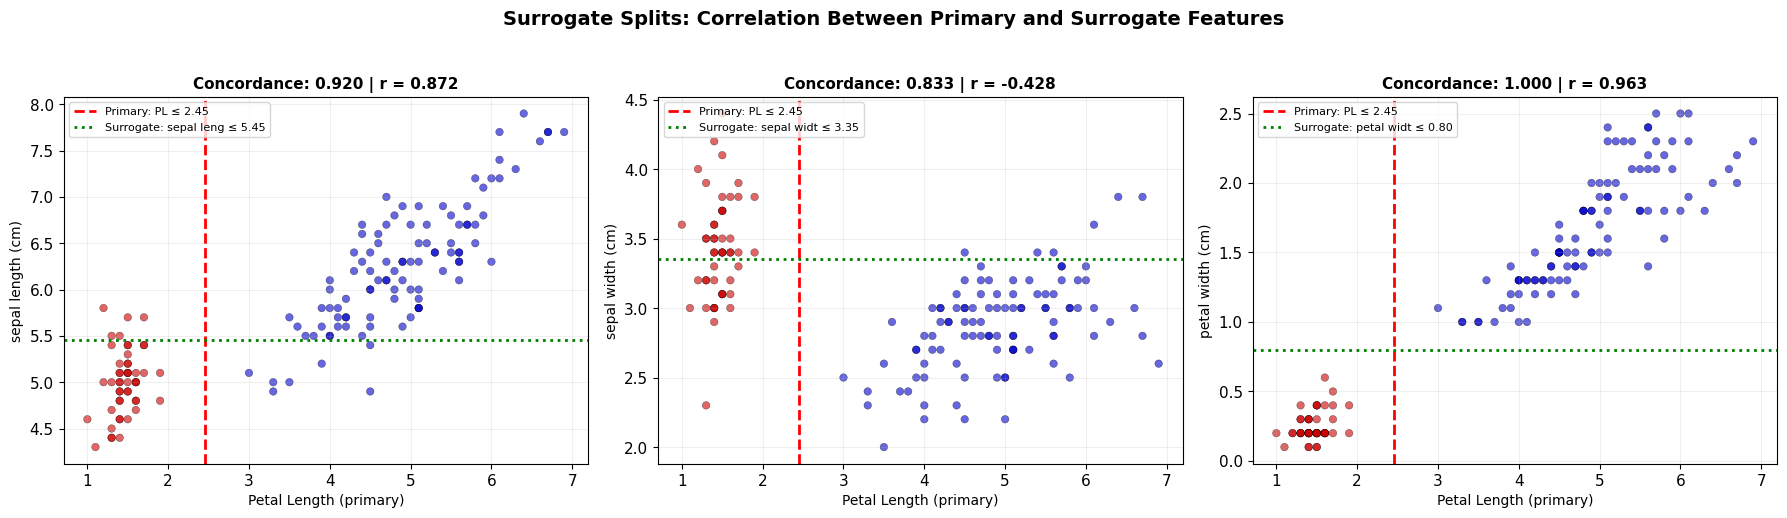


Correlation with Petal Length (primary feature):
     sepal length (cm): r = +0.8718
      sepal width (cm): r = -0.4284
     petal length (cm): r = +1.0000
      petal width (cm): r = +0.9629


In [ ]:
# ──────────────────────────────────────────────────────────────
# Step 4: Visualize why surrogates work — correlation structure
# ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

other_features = [i for i in range(4) if i != primary_feature]
colors = ['#CC0000' if primary_left[j] else '#0000CC' for j in range(n)]

for idx, feat_idx in enumerate(other_features):
    ax = axes[idx]
    ax.scatter(X[:, primary_feature], X[:, feat_idx], c=colors, alpha=0.6, s=30, edgecolors='k', linewidths=0.3)

    # Draw primary split line
    ax.axvline(primary_threshold, color='red', linewidth=2, linestyle='--', label=f'Primary: PL ≤ {primary_threshold}')

    # Draw best surrogate threshold for this feature
    surr = next(s for s in surrogates if s['feature_idx'] == feat_idx)
    ax.axhline(surr['threshold'], color='green', linewidth=2, linestyle=':',
               label=f"Surrogate: {feature_names[feat_idx][:10]} ≤ {surr['threshold']:.2f}")

    corr = np.corrcoef(X[:, primary_feature], X[:, feat_idx])[0, 1]
    ax.set_xlabel(f'Petal Length (primary)', fontsize=10)
    ax.set_ylabel(f'{feature_names[feat_idx]}', fontsize=10)
    ax.set_title(f'Concordance: {surr["concordance"]:.3f} | r = {corr:.3f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.2)

plt.suptitle('Surrogate Splits: Correlation Between Primary and Surrogate Features',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Correlation matrix
print("\nCorrelation with Petal Length (primary feature):")
for feat_idx in range(4):
    corr = np.corrcoef(X[:, primary_feature], X[:, feat_idx])[0, 1]
    print(f"  {feature_names[feat_idx]:>20}: r = {corr:+.4f}")


In [ ]:
# ──────────────────────────────────────────────────────────────
# Step 5: Demonstrate surrogate splits handling missing values
# ──────────────────────────────────────────────────────────────

print("=" * 70)
print("DEMO: Using Surrogate Splits for Missing Data")
print("=" * 70)

# Create 5 test samples — some with missing petal length
np.random.seed(42)
test_samples = pd.DataFrame({
    'sepal_length': [5.1, 6.2, 4.9, 7.0, 5.5],
    'sepal_width':  [3.5, 2.8, 3.1, 3.2, 2.6],
    'petal_length': [1.4, np.nan, np.nan, 6.0, np.nan],  # Some missing!
    'petal_width':  [0.2, 1.3, 0.2, 1.8, 1.5],
    'true_class':   ['setosa', 'versicolor', 'setosa', 'virginica', 'versicolor']
})

print("\nTest samples (NaN = missing petal length):")
print(test_samples.to_string(index=True))
print()

# Apply primary or surrogate split
best_surr = surrogates[0]  # petal width

print("Decision logic at the root node:")
print(f"  PRIMARY:   Petal Length ≤ {primary_threshold}")
print(f"  SURROGATE: {best_surr['feature_name']} ≤ {best_surr['threshold']:.2f} "
      f"(concordance = {best_surr['concordance']:.4f})")
print()

for i, row in test_samples.iterrows():
    pl = row['petal_length']
    pw = row['petal_width']

    if not np.isnan(pl):
        # Use primary split
        direction = "LEFT  (≤ 2.45)" if pl <= primary_threshold else "RIGHT (> 2.45)"
        rule_used = f"Primary: PL = {pl:.1f}"
    else:
        # Use surrogate: petal width
        if best_surr['direction'] == 'normal':
            direction = "LEFT  (≤ surr)" if pw <= best_surr['threshold'] else "RIGHT (> surr)"
        else:
            direction = "RIGHT (> surr)" if pw <= best_surr['threshold'] else "LEFT  (≤ surr)"
        rule_used = f"Surrogate: PW = {pw:.1f} (PL missing!)"

    print(f"  Sample {i}: {rule_used:40s} → {direction}  [true: {row['true_class']}]")

print()
print("💡 Key Insight: When Petal Length is missing, the tree uses Petal Width")
print("   as a surrogate — and because the two features are highly correlated,")
print("   the surrogate produces the SAME routing decision in most cases.")


DEMO: Using Surrogate Splits for Missing Data

Test samples (NaN = missing petal length):
   sepal_length  sepal_width  petal_length  petal_width  true_class
0           5.1          3.5           1.4          0.2      setosa
1           6.2          2.8           NaN          1.3  versicolor
2           4.9          3.1           NaN          0.2      setosa
3           7.0          3.2           6.0          1.8   virginica
4           5.5          2.6           NaN          1.5  versicolor

Decision logic at the root node:
  PRIMARY:   Petal Length ≤ 2.45
  SURROGATE: petal width (cm) ≤ 0.80 (concordance = 1.0000)

  Sample 0: Primary: PL = 1.4                        → LEFT  (≤ 2.45)  [true: setosa]
  Sample 1: Surrogate: PW = 1.3 (PL missing!)        → RIGHT (> surr)  [true: versicolor]
  Sample 2: Surrogate: PW = 0.2 (PL missing!)        → LEFT  (≤ surr)  [true: setosa]
  Sample 3: Primary: PL = 6.0                        → RIGHT (> 2.45)  [true: virginica]
  Sample 4: Surrogate: 

### Summary: Surrogate Splits

| Aspect | Description |
|:-------|:------------|
| **Purpose** | Handle missing values at prediction time without imputation |
| **Mechanism** | Find alternative splits on other features that mimic the primary split |
| **Metric** | Concordance — fraction of samples routed to the same child node |
| **Threshold** | Must exceed the naive rule (always route to majority side) |
| **Bonus** | Reveals which features carry similar information (variable association) |
| **Limitation** | Only in original CART; scikit-learn does not implement surrogates |
| **Alternatives** | XGBoost/LightGBM handle missing values differently (learned default directions) |

**When are surrogates most useful?**
- Datasets with **correlated features** and **sporadic missing values** (e.g., medical data where some tests aren't run on every patient).
- When you need predictions **without imputation** — surrogates are a principled, built-in mechanism.
- When you want to understand **feature redundancy** — high surrogate concordance reveals that two features carry essentially the same information.

---


## 8. Advantages and Disadvantages

### ✅ Advantages

1. **Interpretability**: Trees can be visualized and explained to non-technical audiences. Feature importance is built-in.
2. **No feature scaling needed**: Splits are based on thresholds, not distances — no need to normalize/standardize.
3. **Handles mixed data types**: Can split on numerical and categorical features (with encoding).
4. **Non-parametric**: No assumptions about data distribution or functional form.
5. **Captures non-linearity and interactions**: Multi-level splits naturally model feature interactions.
6. **Fast prediction**: $O(\text{depth})$ per sample.
7. **Built-in feature selection**: Features not used in any split are effectively ignored.
8. **Handles missing values**: Some implementations (XGBoost, LightGBM) natively handle NaNs; scikit-learn requires imputation.

### ❌ Disadvantages

1. **High variance**: Small changes in data can produce completely different trees (**instability**).
2. **Overfitting**: Deep trees memorize training data. Requires careful pruning/regularization.
3. **Axis-aligned splits only**: Cannot efficiently capture diagonal or curved boundaries (needs many splits to approximate).
4. **Greedy algorithm**: Locally optimal splits ≠ globally optimal tree.
5. **Biased toward features with many levels**: Features with more unique values have more candidate splits, giving them an unfair advantage.
6. **Poor extrapolation** (regression): Predictions are constant in leaf regions — cannot predict outside training range.
7. **Class imbalance sensitivity**: Majority class dominates Gini/entropy without balancing.

### The Bias-Variance Perspective

| Model | Bias | Variance |
|:------|:-----|:---------|
| Shallow tree (high pruning) | High | Low |
| Deep tree (no pruning) | Low | High |
| Random Forest (ensemble of trees) | Low | Lower |
| Gradient Boosted Trees | Low | Low |

> CART trees are the **building blocks** of the most powerful ML ensembles: Random Forests, AdaBoost, Gradient Boosted Trees (XGBoost, LightGBM, CatBoost).


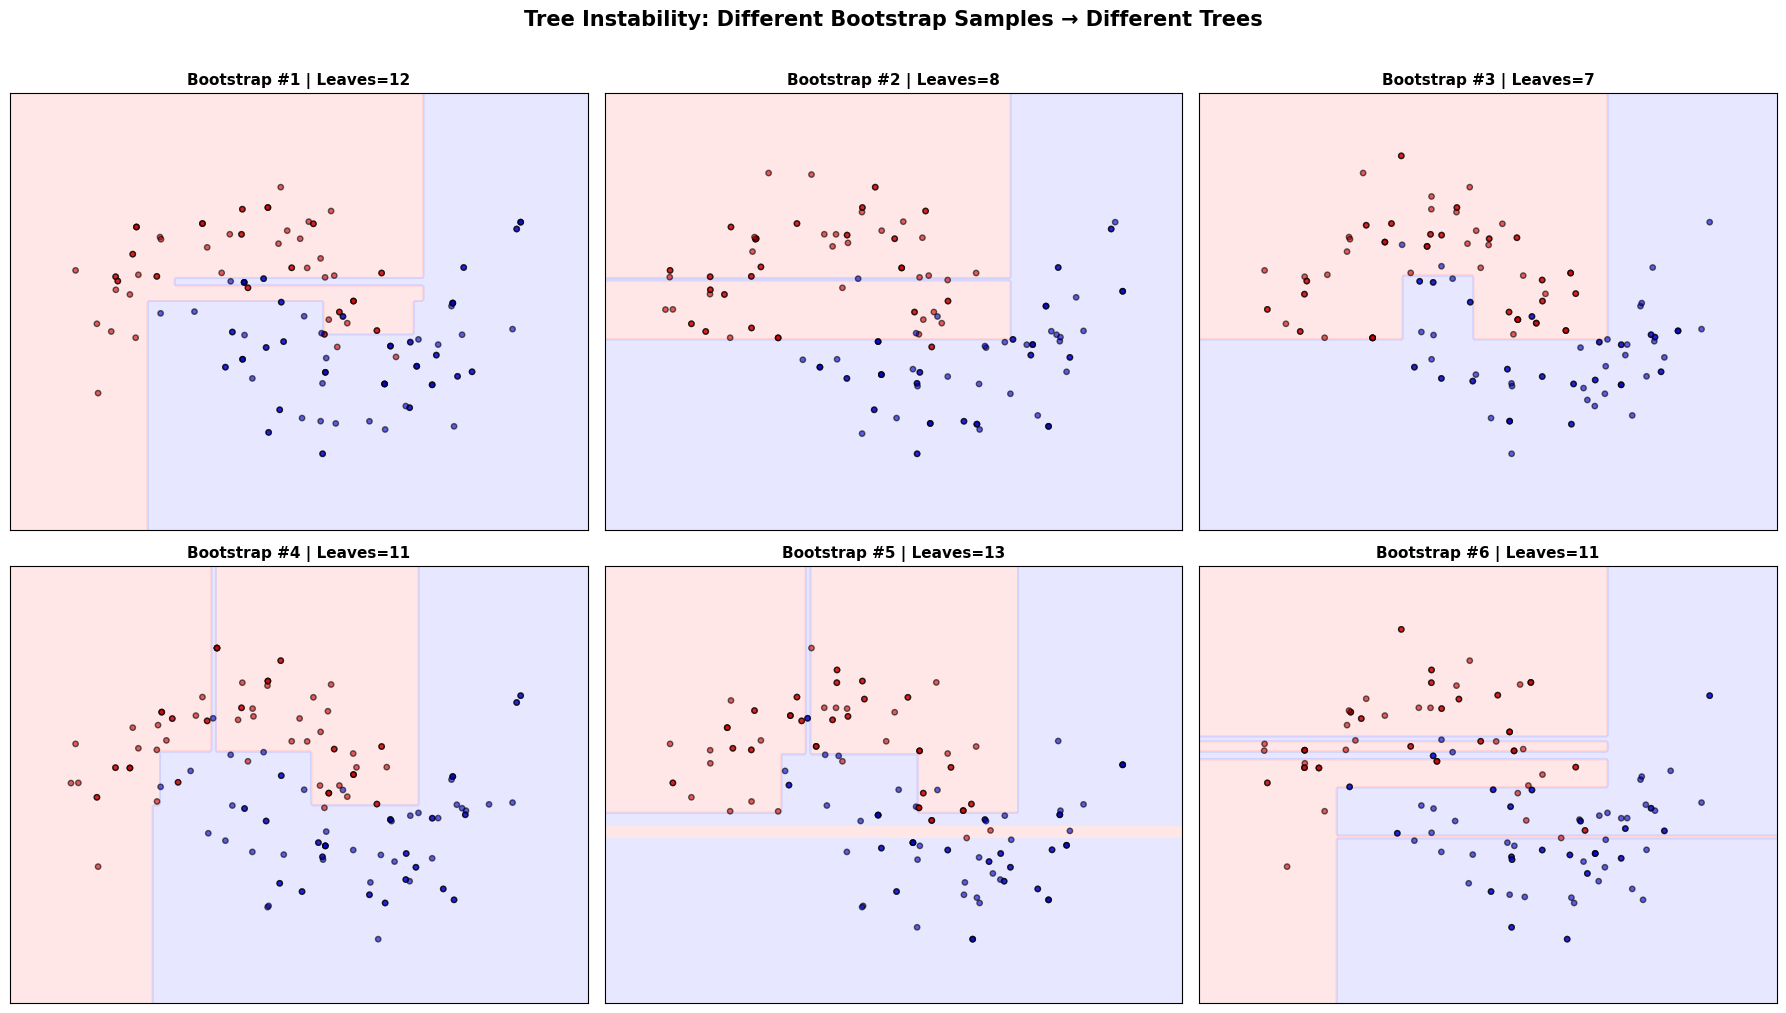

💡 Notice how different data samples produce very different decision boundaries!
   This high variance is WHY ensemble methods (Random Forest, Boosting) are preferred.


In [ ]:
# Demonstration: Instability of decision trees
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

X_base, y_base = make_moons(n_samples=150, noise=0.25, random_state=42)

h = 0.02
x_min, x_max = X_base[:, 0].min() - 0.5, X_base[:, 0].max() + 0.5
y_min, y_max = X_base[:, 1].min() - 0.5, X_base[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

cmap_light = ListedColormap(['#FFD1D1', '#D1D1FF'])
cmap_bold = ListedColormap(['#CC0000', '#0000CC'])

for i in range(6):
    ax = axes.ravel()[i]
    # Bootstrap sample (simulating slight data changes)
    np.random.seed(i * 10 + 7)
    idx = np.random.choice(len(X_base), size=len(X_base), replace=True)
    X_boot, y_boot = X_base[idx], y_base[idx]

    tree = DecisionTreeClassifier(max_depth=5, random_state=42)
    tree.fit(X_boot, y_boot)
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)
    ax.scatter(X_boot[:, 0], X_boot[:, 1], c=y_boot, cmap=cmap_bold,
               edgecolors='k', s=15, alpha=0.6)
    ax.set_title(f'Bootstrap #{i+1} | Leaves={tree.get_n_leaves()}', fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Tree Instability: Different Bootstrap Samples → Different Trees',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("💡 Notice how different data samples produce very different decision boundaries!")
print("   This high variance is WHY ensemble methods (Random Forest, Boosting) are preferred.")


## 9. Use Case: End-to-End CART Pipeline

Let's build a complete, realistic CART pipeline on the **Wine Quality** dataset using scikit-learn's built-in wine dataset. We'll demonstrate:

1. Data exploration
2. Train/test split
3. Full tree (overfitting)
4. Pre-pruning
5. Post-pruning with cross-validated alpha
6. Model interpretation (feature importance, individual predictions)


In [ ]:
# Step 1: Load and explore the dataset
from sklearn.datasets import load_wine

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='class')

print("Dataset shape:", X.shape)
print(f"Classes: {wine.target_names} (counts: {np.bincount(y)})\n")
print(X.describe().round(2).to_string())


Dataset shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2'] (counts: [59 71 48])

       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity     hue  od280/od315_of_diluted_wines  proline
count   178.00      178.00  178.00             178.00     178.00         178.00      178.00                178.00           178.00           178.00  178.00                        178.00   178.00
mean     13.00        2.34    2.37              19.49      99.74           2.30        2.03                  0.36             1.59             5.06    0.96                          2.61   746.89
std       0.81        1.12    0.27               3.34      14.28           0.63        1.00                  0.12             0.57             2.32    0.23                          0.71   314.91
min      11.03        0.74    1.36              10.60      70.00           0.98        0.34                  0.13             0.41  

In [ ]:
# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:  {np.bincount(y_test)}")


Train: 133 samples
Test:  45 samples
Train class distribution: [44 53 36]
Test class distribution:  [15 18 12]


In [ ]:
# Step 3: Full tree (no pruning) — expect overfitting
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

print("=== Full Tree (no restrictions) ===")
print(f"Depth: {full_tree.get_depth()}")
print(f"Leaves: {full_tree.get_n_leaves()}")
print(f"Train Accuracy: {full_tree.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {full_tree.score(X_test, y_test):.4f}")
print(f"Gap (overfit indicator): {full_tree.score(X_train, y_train) - full_tree.score(X_test, y_test):.4f}")


=== Full Tree (no restrictions) ===
Depth: 4
Leaves: 8
Train Accuracy: 1.0000
Test Accuracy:  0.9556
Gap (overfit indicator): 0.0444


=== Pre-Pruned Tree ===
Depth: 3
Leaves: 6
Train Accuracy: 0.9699
Test Accuracy:  0.9556


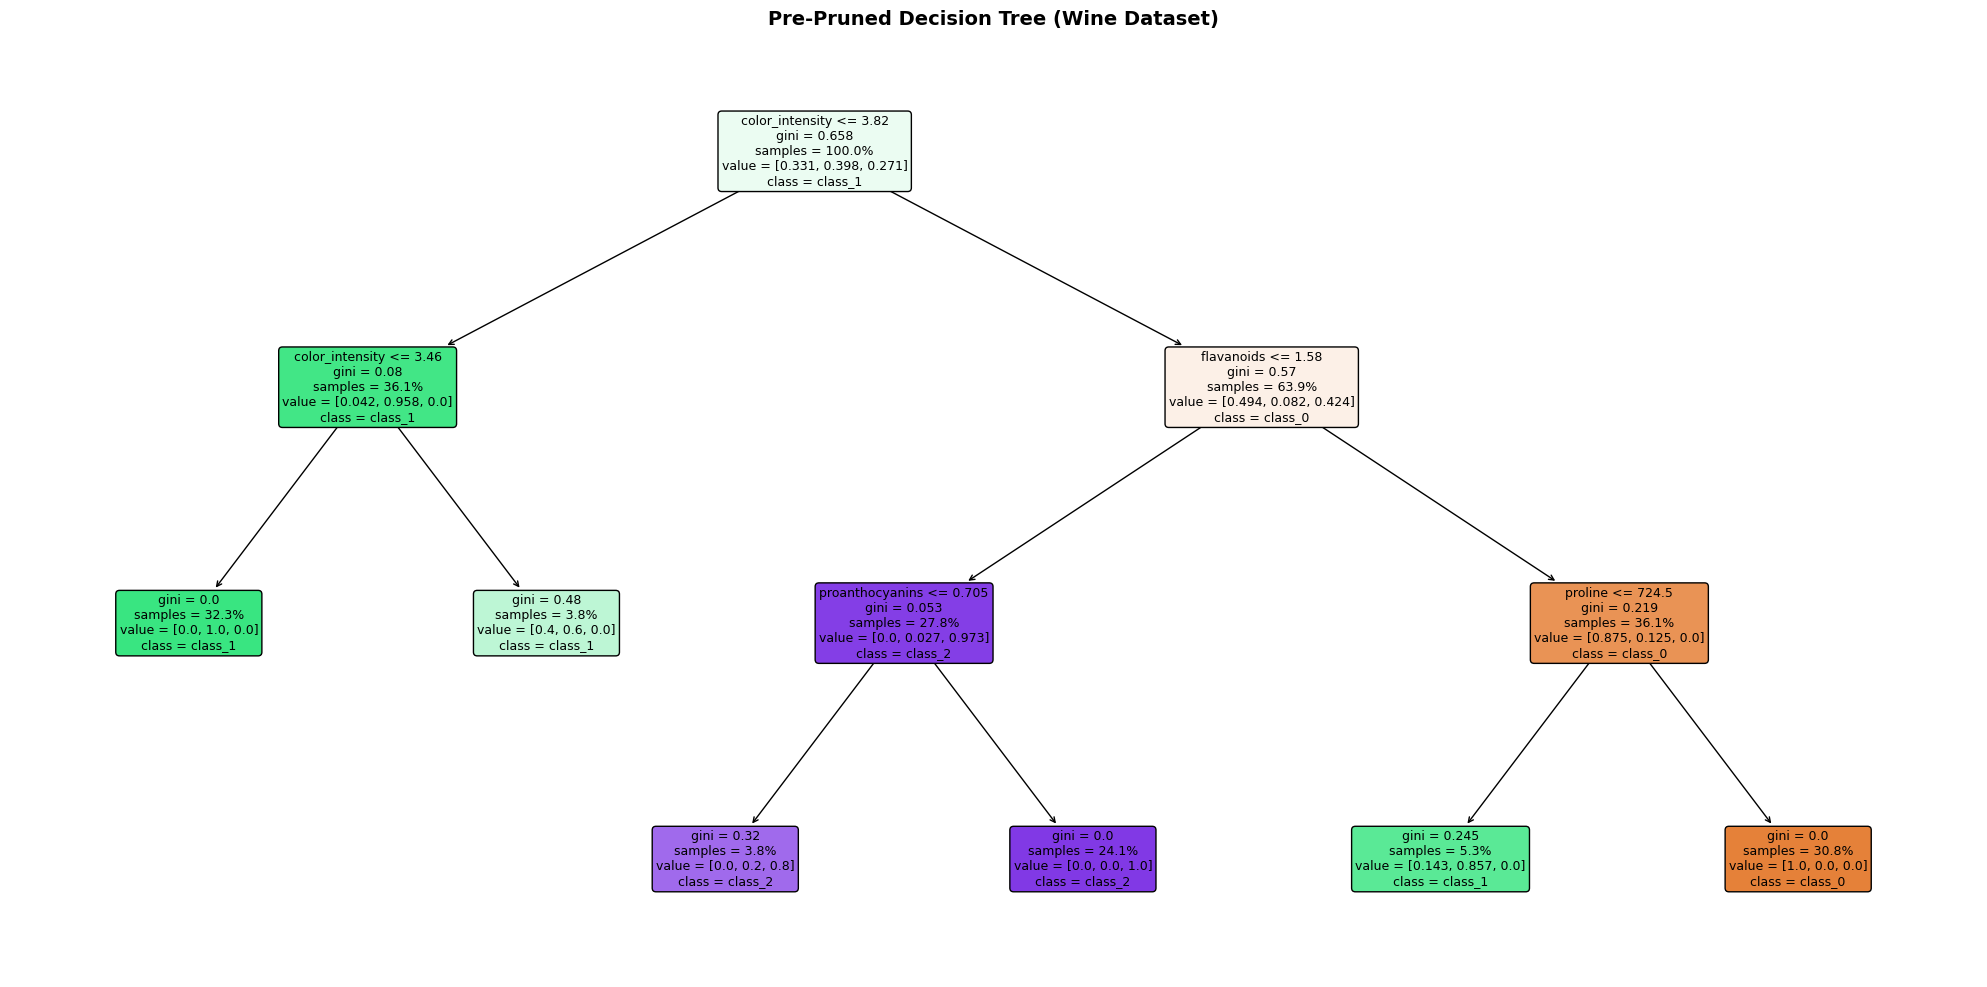

In [ ]:
# Step 4: Pre-pruned tree
pre_pruned = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
pre_pruned.fit(X_train, y_train)

print("=== Pre-Pruned Tree ===")
print(f"Depth: {pre_pruned.get_depth()}")
print(f"Leaves: {pre_pruned.get_n_leaves()}")
print(f"Train Accuracy: {pre_pruned.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {pre_pruned.score(X_test, y_test):.4f}")

# Visualize the pre-pruned tree
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pre_pruned, feature_names=wine.feature_names,
          class_names=wine.target_names, filled=True, rounded=True,
          fontsize=9, ax=ax, proportion=True)
ax.set_title('Pre-Pruned Decision Tree (Wine Dataset)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Step 5: Post-pruning with cross-validated alpha selection
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # exclude trivial tree (root only)

# Cross-validate each alpha
cv_results = []
for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='accuracy')
    cv_results.append({
        'alpha': alpha,
        'cv_mean': scores.mean(),
        'cv_std': scores.std(),
        'n_leaves': DecisionTreeClassifier(ccp_alpha=alpha, random_state=42).fit(X_train, y_train).get_n_leaves()
    })

cv_df = pd.DataFrame(cv_results)
best_row = cv_df.loc[cv_df['cv_mean'].idxmax()]

# 1-SE rule
threshold_1se = best_row['cv_mean'] - best_row['cv_std']
se_candidates = cv_df[cv_df['cv_mean'] >= threshold_1se]
se_best = se_candidates.iloc[-1]  # largest alpha above threshold

print(f"Best CV alpha:  {best_row['alpha']:.6f} (CV acc: {best_row['cv_mean']:.4f} ± {best_row['cv_std']:.4f}, leaves: {int(best_row['n_leaves'])})")
print(f"1-SE Rule alpha: {se_best['alpha']:.6f} (CV acc: {se_best['cv_mean']:.4f} ± {se_best['cv_std']:.4f}, leaves: {int(se_best['n_leaves'])})")

# Final model
final_model = DecisionTreeClassifier(ccp_alpha=se_best['alpha'], random_state=42)
final_model.fit(X_train, y_train)

print(f"\n=== Final Post-Pruned Tree (1-SE Rule) ===")
print(f"Depth: {final_model.get_depth()}")
print(f"Leaves: {final_model.get_n_leaves()}")
print(f"Train Accuracy: {final_model.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {final_model.score(X_test, y_test):.4f}")


Best CV alpha:  0.000000 (CV acc: 0.8954 ± 0.0756, leaves: 8)
1-SE Rule alpha: 0.066058 (CV acc: 0.8650 ± 0.0988, leaves: 3)

=== Final Post-Pruned Tree (1-SE Rule) ===
Depth: 2
Leaves: 3
Train Accuracy: 0.9323
Test Accuracy:  0.8667


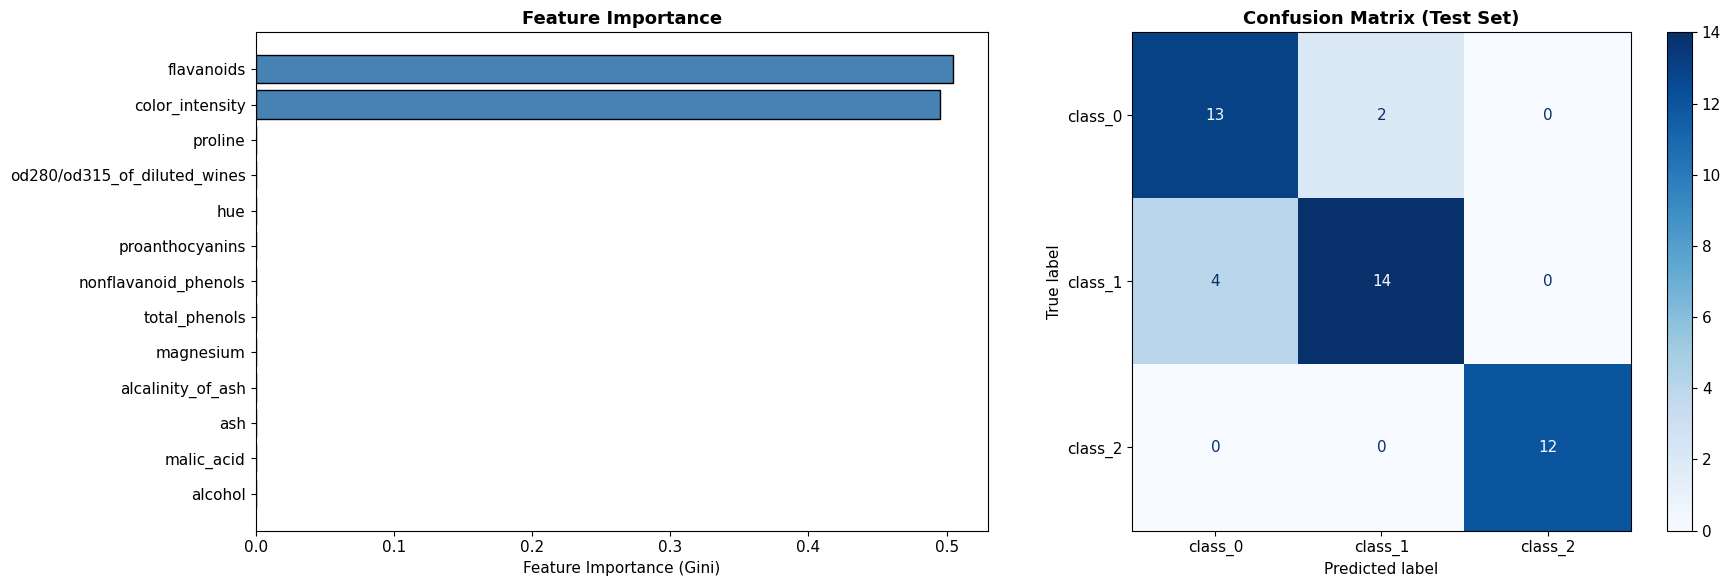


=== Classification Report (Test Set) ===

              precision    recall  f1-score   support

     class_0       0.76      0.87      0.81        15
     class_1       0.88      0.78      0.82        18
     class_2       1.00      1.00      1.00        12

    accuracy                           0.87        45
   macro avg       0.88      0.88      0.88        45
weighted avg       0.87      0.87      0.87        45



In [ ]:
# Step 6: Model interpretation
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Feature Importance
importances = final_model.feature_importances_
sorted_idx = np.argsort(importances)
axes[0].barh(range(len(sorted_idx)), importances[sorted_idx], color='steelblue', edgecolor='k')
axes[0].set_yticks(range(len(sorted_idx)))
axes[0].set_yticklabels(np.array(wine.feature_names)[sorted_idx])
axes[0].set_xlabel('Feature Importance (Gini)')
axes[0].set_title('Feature Importance', fontsize=13, fontweight='bold')

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    final_model, X_test, y_test, display_labels=wine.target_names,
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Classification report
print("\n=== Classification Report (Test Set) ===\n")
print(classification_report(y_test, final_model.predict(X_test),
                            target_names=wine.target_names))


In [ ]:
# Comparison summary
print("=" * 65)
print(f"{'Model':<25} {'Depth':>6} {'Leaves':>7} {'Train':>8} {'Test':>8}")
print("=" * 65)

models = {
    'Full (no pruning)': full_tree,
    'Pre-pruned': pre_pruned,
    'Post-pruned (1-SE)': final_model,
}

for name, model in models.items():
    print(f"{name:<25} {model.get_depth():>6} {model.get_n_leaves():>7} "
          f"{model.score(X_train, y_train):>8.4f} {model.score(X_test, y_test):>8.4f}")

print("=" * 65)
print("\n💡 Key Takeaway: Pruning reduces overfitting and often improves test performance.")
print("   The pruned model is also much more interpretable than the full tree.")


Model                      Depth  Leaves    Train     Test
Full (no pruning)              4       8   1.0000   0.9556
Pre-pruned                     3       6   0.9699   0.9556
Post-pruned (1-SE)             2       3   0.9323   0.8667

💡 Key Takeaway: Pruning reduces overfitting and often improves test performance.
   The pruned model is also much more interpretable than the full tree.


## Summary

| Topic | Key Takeaway |
|:------|:-------------|
| **Nutshell** | CART recursively partitions feature space via binary splits |
| **Predictions** | Traverse root→leaf; return majority vote or mean |
| **Growing** | Top-down, greedy selection of best split at each node |
| **Regression splits** | Minimize MSE (variance) in child nodes |
| **Classification splits** | Minimize Gini impurity or entropy |
| **Gini vs Entropy (Iris)** | Both agree on optimal splits; Gini avoids log computation |
| **Computation** | Sort once per feature, scan incrementally — $O(pn\log n)$ per node |
| **Pruning** | Pre-pruning (stop early) + post-pruning (cost-complexity with CV) |
| **Surrogate Splits** | Handle missing data by using correlated features as backup splits |
| **Pros** | Interpretable, no scaling needed, handles non-linearity |
| **Cons** | High variance, overfitting, axis-aligned only, greedy |
| **Use case** | Foundation for ensembles; excellent for interpretable models |

### Further Reading
- Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). *Classification and Regression Trees*. Wadsworth.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*, Chapter 9.
- scikit-learn documentation: [Decision Trees](https://scikit-learn.org/stable/modules/tree.html)
